In [ ]:
## ==========================================================================
## Phase 1: Project Setup & Configuration (Modified for Student B's Method)
## ==========================================================================
## This cell handles all necessary imports, sets up global configurations,
## and prepares the environment for reproducibility.
## MODIFIED: Using Pearson correlation + hybrid multiple thresholds

# --- Imports ---
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from PIL import Image
import time
import matplotlib.pyplot as plt
import pandas as pd  # For CSV handling

# --- Configuration & Hyperparameters ---
CONFIG = {
    "RANDOM_SEED": 42,
    "LR": 1e-3,                # learning rate
    "BATCH_SIZE": 64,
    "EPOCHS": 5,
    "IMG_SIZE": (128, 128),    # height, width
    "NUM_CLASSES": 2,          # gender classification (male vs. female)
    "DATA_DIR": "./data",
    "TRAIN_SAMPLES": 10000,
    "VAL_SAMPLES": 2000,
    "GENDER_ATTR_INDEX": 20,   # attribute index for "Male"

    # Student B's method specific parameters
    "SIMILARITY_METRIC": "pearson",          # Pearson correlation
    "CORR_THRESHOLDS": [0.9, 0.75],          # high vs medium correlation
    "MAG_THRESHOLDS": [0.02, 0.01],          # magnitude cutoffs
}

print(f"--- Student B's Method Configuration ---")
print(f"Task: Gender Classification (Male vs. Female)")
print(f"Similarity metric: {CONFIG['SIMILARITY_METRIC']}")
print(f"Correlation thresholds: {CONFIG['CORR_THRESHOLDS']}")
print(f"Magnitude thresholds: {CONFIG['MAG_THRESHOLDS']}")
print(f"Training samples: {CONFIG['TRAIN_SAMPLES']:,}")

# --- Make sure data directory exists ---
os.makedirs(CONFIG["DATA_DIR"], exist_ok=True)

# --- Seed everything for reproducibility ---
random.seed(CONFIG["RANDOM_SEED"])
np.random.seed(CONFIG["RANDOM_SEED"])
torch.manual_seed(CONFIG["RANDOM_SEED"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["RANDOM_SEED"])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# --- Device Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- Environment Setup ---")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name()}")
print("-" * 40)

# --- Optional: quick transforms sanity-check ---
try:
    _ = transforms.Compose([
        transforms.Resize(CONFIG["IMG_SIZE"]),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                             std=[0.229,0.224,0.225])
    ])
    print("✅ Transforms OK")
except Exception as e:
    print(f"❌ Error in transforms: {e}")

# --- Worker seeding helper for DataLoader ---
def seed_worker(worker_id):
    worker_seed = CONFIG["RANDOM_SEED"] + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)

# --- Helper function for finding image directory ---
def find_image_dir(root):
    """Find the CelebA image directory automatically"""
    for dirpath, dirnames, filenames in os.walk(root):
        jpgs = [f for f in filenames if f.lower().endswith(".jpg")]
        if len(jpgs) > 1000:  # heuristic: >1k .jpgs means this is the images folder
            return dirpath
    raise FileNotFoundError("Couldn't find img_align_celeba folder with images")

print("✅ Setup complete. Ready for Student B's hybrid multiple-threshold method.")
print("📋 Next steps:")
print("   1. Load and train baseline CNN model")
print("   2. Extract Layer 5 features sequentially")
print("   3. Implement Pearson correlation similarity")
print("   4. Apply hybrid multiple-threshold pruning")
print("   5. Determine fraction of removable filters")
print("-" * 40)


--- Student B's Method Configuration ---
Task: Gender Classification (Male vs. Female)
Similarity metric: pearson
Correlation thresholds: [0.9, 0.75]
Magnitude thresholds: [0.02, 0.01]
Training samples: 10,000

--- Environment Setup ---
Using device: cuda
PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA device: Tesla T4
----------------------------------------
✅ Transforms OK
✅ Setup complete. Ready for Student B's hybrid multiple-threshold method.
📋 Next steps:
   1. Load and train baseline CNN model
   2. Extract Layer 5 features sequentially
   3. Implement Pearson correlation similarity
   4. Apply hybrid multiple-threshold pruning
   5. Determine fraction of removable filters
----------------------------------------


In [ ]:
# ------------------------------------------------------------------------------
# Week 1.1: Baseline CNN Architecture (Naga's Task) — Enhanced
# ------------------------------------------------------------------------------
import torch.nn as nn

class CNN_V1(nn.Module):
    def __init__(self, num_classes=CONFIG["NUM_CLASSES"]):
        super().__init__()

        # feature extractor: 5 conv blocks with BatchNorm + ReLU + MaxPool
        self.features = nn.Sequential(
            # Block 1: 3→64
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 64→128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 128→256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 256→512
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 5: 512→512
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # compute flattened feature size after 5 pools
        h, w = CONFIG["IMG_SIZE"]
        downscale = 2 ** 5  # 5 pooling layers
        flat_dim = (h // downscale) * (w // downscale) * 512

        # classifier head with a hidden layer + dropout
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(flat_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
            # no sigmoid here—use CrossEntropyLoss or BCEWithLogitsLoss
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# instantiate & count params
model = CNN_V1().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"--- Phase 1.1: Enhanced CNN_V1 — {total_params:,} trainable parameters ---")


--- Phase 1.1: Enhanced CNN_V1 — 12,305,410 trainable parameters ---


In [ ]:
# HE Intialisation - Needs to be same as what Ashwini Used.
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
model.apply(init_weights)

CNN_V1(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, af

In [ ]:
pip install moviepy


In [ ]:
# ------------------------------------------------------------------------------
# Week 1.2 - Download CelebA via Kaggle API into Colab VM
# ------------------------------------------------------------------------------

# 1) Install & authenticate Kaggle
!pip install kaggle --quiet

from google.colab import files
# This will prompt you to upload your kaggle.json
files.upload()

# 2) Move your kaggle.json into place
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3) Create download target & fetch
!mkdir -p /content/celeba
!kaggle datasets download -d jessicali9530/celeba-dataset -p /content/celeba

# 4) Unzip the dataset
!unzip -q /content/celeba/celeba-dataset.zip -d /content/celeba

# 5) Update CONFIG to point at the new local copy
CONFIG["DATA_DIR"] = "/content/celeba"
celeba_folder = os.path.join(CONFIG["DATA_DIR"], "img_align_celeba").replace("img_align_celeba","")  # root of celeba

print(f"✅ Downloaded and unpacked CelebA into {CONFIG['DATA_DIR']}")

# 6) Now you can reuse the custom loader from earlier, e.g.:

# from torchvision import transforms
# data_transforms = transforms.Compose([...])
# train_ds = CelebACustom(train_df, os.path.join(CONFIG["DATA_DIR"],"img_align_celeba"), transform=data_transforms)
# ... etc.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
 99% 1.31G/1.33G [00:12<00:00, 40.5MB/s]
100% 1.33G/1.33G [00:12<00:00, 119MB/s] 
✅ Downloaded and unpacked CelebA into /content/celeba


In [ ]:
# @title
# ------------------------------------------------------------------------------
# Phase 1.4: Data Pipeline (Shared between Student A & B)
# ------------------------------------------------------------------------------
# Both Student A (IoU-based) and Student B (Pearson-based multiple thresholding)
# use the SAME CelebA gender classification dataset.
# The only difference: Student A requires a sequential loader for IoU analysis,
# while Student B does not (but we keep it for consistency in comparisons).
# ------------------------------------------------------------------------------

import os, random, zipfile
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("--- Data Pipeline Setup (Shared) ---")
print("Task: Gender Classification (Male vs. Female)")

# 1) Dataset root (already extracted in Cell 4)
CONFIG["DATA_DIR"] = "/content/celeba"
celeba_folder = CONFIG["DATA_DIR"]

# 2) Locate image directory
img_dir = find_image_dir(celeba_folder)
print(f"→ Using img_dir = {img_dir}")

# 3) Verify metadata
for fn in ["list_attr_celeba.csv","list_eval_partition.csv"]:
    fp = os.path.join(celeba_folder, fn)
    assert os.path.exists(fp), f"Missing file: {fp}"
print("✅ CSV metadata found.")

# 4) Load attributes & partitions
attrs = pd.read_csv(os.path.join(celeba_folder, "list_attr_celeba.csv"))
parts = pd.read_csv(os.path.join(celeba_folder, "list_eval_partition.csv"))
df = attrs.merge(parts, on="image_id")

print(f"Dataset info: {len(df):,} images total")

# Ensure 'Male' column exists
if 'Male' not in df.columns:
    raise ValueError("'Male' attribute missing from metadata!")

# 5) Create splits
train_df = df[df["partition"]==0].sample(CONFIG["TRAIN_SAMPLES"],
                                         random_state=CONFIG["RANDOM_SEED"])
valid_df = df[df["partition"]==1].sample(CONFIG["VAL_SAMPLES"],
                                         random_state=CONFIG["RANDOM_SEED"])
train_df_sequential = df[df["partition"]==0].iloc[:CONFIG["TRAIN_SAMPLES"]]

print(f"✅ Train/Valid splits created")

# 6) Transforms (same for both methods)
data_transforms = transforms.Compose([
    transforms.Resize(CONFIG["IMG_SIZE"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# 7) Custom Dataset
class CelebACustom(Dataset):
    def __init__(self, df, img_dir, transform=None, task='gender'):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.task = task

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.img_dir, row["image_id"])
        img = Image.open(path).convert("RGB")

        if self.task == 'gender':
            label = int((row["Male"] + 1) // 2)  # Male=1, Female=0
        else:
            label = int((row["Smiling"] + 1) // 2)  # fallback

        if self.transform:
            img = self.transform(img)
        return img, label

# 8) Create Datasets
train_ds = CelebACustom(train_df, img_dir, data_transforms, task='gender')
valid_ds = CelebACustom(valid_df, img_dir, data_transforms, task='gender')
sequential_ds = CelebACustom(train_df_sequential, img_dir, data_transforms, task='gender')

# 9) Create Loaders
g = torch.Generator().manual_seed(CONFIG["RANDOM_SEED"])

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"],
                          shuffle=True, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=g)

valid_loader = DataLoader(valid_ds, batch_size=CONFIG["BATCH_SIZE"],
                          shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=g)

# Sequential loader used in Student A/Professor's method only
sequential_loader = DataLoader(sequential_ds, batch_size=1,
                               shuffle=False, num_workers=2, pin_memory=True,
                               worker_init_fn=seed_worker, generator=g)

print(f"✅ DataLoaders created")
print(f"  Train: {len(train_loader)} batches (shuffled)")
print(f"  Valid: {len(valid_loader)} batches")
print(f"  Sequential: {len(sequential_loader)} batches (unused in Student B method)")


--- Data Pipeline Setup (Shared) ---
Task: Gender Classification (Male vs. Female)
→ Using img_dir = /content/celeba/img_align_celeba/img_align_celeba
✅ CSV metadata found.
Dataset info: 202,599 images total
✅ Train/Valid splits created
✅ DataLoaders created
  Train: 157 batches (shuffled)
  Valid: 32 batches
  Sequential: 10000 batches (unused in Student B method)


**Phase 2**

In [ ]:
# @title
# ------------------------------------------------------------------------------
# Phase 1.5: Smoke Test (Shared between Student A & B)
# ------------------------------------------------------------------------------
# Purpose: Verify that the CNN model and DataLoaders are compatible
# - Checks forward & backward passes
# - Ensures shapes match
# - Reports timing
# This utility is identical for Student A (IoU method) and Student B (Pearson method).
# ------------------------------------------------------------------------------

import time
import torch.nn as nn

# Use CrossEntropyLoss since our CNN outputs logits for two classes (Female=0, Male=1)
criterion = nn.CrossEntropyLoss()

def run_smoke_test(model, loader, device, criterion=None):
    """
    Runs a single forward (and optional backward) pass to ensure
    the data pipeline and model are compatible, and measures timing.

    Args:
        model: CNN model
        loader: DataLoader (train/valid, random sampling)
        device: 'cpu' or 'cuda'
        criterion: loss function (optional, enables backward pass test)
    """
    print("--- Phase 1.5: Running Smoke Test ---")
    model.to(device)
    model.train()

    # 1) Fetch one batch
    try:
        data, target = next(iter(loader))
    except StopIteration:
        print("❌ Smoke Test FAILED: DataLoader is empty.")
        return False

    data, target = data.to(device), target.to(device)

    # 2) Forward pass timing
    if device == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    output = model(data)
    if device == 'cuda': torch.cuda.synchronize()
    t_fwd = (time.perf_counter() - t0) * 1000
    print(f"Forward pass time: {t_fwd:.2f} ms")

    # 3) Shape checks
    print(f"Input shape : {data.shape}   # [batch, 3, H, W]")
    print(f"Target shape: {target.shape}   # [batch]")
    print(f"Output shape: {output.shape}   # [batch, num_classes]")

    # 4) Dummy loss & backward (if criterion provided)
    if criterion is not None:
        loss = criterion(output, target)
        loss.backward()
        print(f"Backward pass succeeded. Loss: {loss.item():.4f}")

    # 5) Simple batch accuracy
    preds = output.argmax(dim=1)
    correct = (preds == target).sum().item()
    print(f"Batch accuracy: {correct}/{target.size(0)} = {correct/target.size(0):.4f}")

    # 6) Layer-by-layer feature timing (optional diagnostic)
    print("\nLayer-by-layer timing (features):")
    with torch.no_grad():
        x = data.clone()
        for name, layer in model.features.named_children():
            if device == 'cuda': torch.cuda.synchronize()
            t0 = time.perf_counter()
            x = layer(x)
            if device == 'cuda': torch.cuda.synchronize()
            print(f"  {name:>10}: {(time.perf_counter()-t0)*1000:6.2f} ms")

    print("✅ Smoke Test PASSED: Model and data pipeline are compatible.\n")
    return True


In [ ]:
# @title
# ------------------------------------------------------------------------------
# Cell 7: Define output directories for logs & checkpoints
# ------------------------------------------------------------------------------
# Purpose:
# - Keeps training logs (CSV) and model checkpoints organized by phase
# - Works for both Student A (IoU method) and Student B (Pearson method)
# - No changes are needed in Student B’s pipeline
# ------------------------------------------------------------------------------

import os

OUTPUT_ROOT = "./output"
PHASE       = "phase_2"   # Options: "phase_1" for Week 1, "phase_2" for Week 2, etc.

# Define paths
LOG_DIR     = os.path.join(OUTPUT_ROOT, f"{PHASE}_logs")
CKPT_DIR    = os.path.join(OUTPUT_ROOT, f"{PHASE}_checkpoints")

# Create directories if they don’t exist
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# Update CONFIG so training code uses these paths automatically
CONFIG["LOG_PATH"] = os.path.join(LOG_DIR, "experiment_log.csv")
CONFIG["SAVE_DIR"] = CKPT_DIR

print(f"→ Logs will be saved to:       {CONFIG['LOG_PATH']}")
print(f"→ Checkpoints will be saved to: {CONFIG['SAVE_DIR']}")


→ Logs will be saved to:       ./output/phase_2_logs/experiment_log.csv
→ Checkpoints will be saved to: ./output/phase_2_checkpoints


In [ ]:
# @title
# ------------------------------------------------------------------------------
# Cell 8: Model Training & Evaluation (Unchanged for Student B)
# ------------------------------------------------------------------------------
# Purpose:
# - Train CNN with CrossEntropyLoss + Adam
# - Log metrics to CSV
# - Save best model checkpoint
# Notes:
# - Student B (Pearson multiple thresholds) uses the trained model features
#   AFTER training, so training loop is identical to Student A.
# ------------------------------------------------------------------------------

from tqdm import tqdm

# Utility to append metrics to CSV log
def append_log(entry):
    log_path = CONFIG["LOG_PATH"]
    if os.path.exists(log_path):
        df = pd.read_csv(log_path)
    else:
        df = pd.DataFrame()
    df = pd.concat([df, pd.DataFrame([entry])], ignore_index=True)
    df.to_csv(log_path, index=False)

def train_and_evaluate(model, train_loader, val_loader, config, device):
    """
    Train CNN for config["EPOCHS"] epochs, validate each epoch,
    log metrics, and save the best model checkpoint.
    """
    print(f"\n--- Phase 2.1: Training for {config['EPOCHS']} epochs ---\n")

    # Loss & optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["LR"])

    best_val_acc = 0.0
    os.makedirs(config["SAVE_DIR"], exist_ok=True)

    for epoch in range(1, config["EPOCHS"] + 1):
        epoch_start = time.time()

        # ---------------- Training ----------------
        model.train()
        running_loss = 0.0
        correct = total = 0

        for imgs, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{config['EPOCHS']}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---------------- Validation ----------------
        model.eval()
        val_loss = val_correct = val_total = 0
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"[ Val ] Epoch {epoch}/{config['EPOCHS']}"):
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * imgs.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total
        epoch_time = time.time() - epoch_start

        # ---------------- Logging & Checkpointing ----------------
        # 1) Append metrics
        append_log({
            "date":       pd.Timestamp.now().strftime("%Y-%m-%d"),
            "phase":      PHASE,
            "epoch":      epoch,
            "batch_size": config["BATCH_SIZE"],
            "lr":         config["LR"],
            "train_loss": train_loss,
            "train_acc":  train_acc,
            "val_loss":   val_loss,
            "val_acc":    val_acc,
            "epoch_time_s": epoch_time
        })

        # 2) Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            ckpt_name = f"best_epoch{epoch:02d}_acc{val_acc:.4f}.pth"
            ckpt_path = os.path.join(config["SAVE_DIR"], ckpt_name)
            torch.save(model.state_dict(), ckpt_path)
            print(f"  ↑ New best model saved: {ckpt_path}")

        # 3) Print summary
        print(f"\nEpoch {epoch}/{config['EPOCHS']} — "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.1f}s\n")

    print(f"--- Training Complete: Best Val Acc = {best_val_acc:.4f} ---\n")
    print(f"Logs 👉 {config['LOG_PATH']}")
    print(f"Checkpoints 👉 {config['SAVE_DIR']}")
    print("-" * 30)

    return

# Only run if smoke test passed
if run_smoke_test(model, train_loader, DEVICE, criterion=nn.CrossEntropyLoss()):
    train_and_evaluate(model, train_loader, valid_loader, CONFIG, DEVICE)


--- Phase 1.5: Running Smoke Test ---
Forward pass time: 1388.67 ms
Input shape : torch.Size([64, 3, 128, 128])   # [batch, 3, H, W]
Target shape: torch.Size([64])   # [batch]
Output shape: torch.Size([64, 2])   # [batch, num_classes]
Backward pass succeeded. Loss: 1.9502
Batch accuracy: 35/64 = 0.5469

Layer-by-layer timing (features):
           0:   0.27 ms
           1:   0.22 ms
           2:   0.05 ms
           3:   0.09 ms
           4:   0.17 ms
           5:   0.14 ms
           6:   0.04 ms
           7:   0.05 ms
           8:   0.12 ms
           9:   0.12 ms
          10:   0.03 ms
          11:   0.04 ms
          12:   0.13 ms
          13:   0.13 ms
          14:   0.03 ms
          15:   0.04 ms
          16:   0.11 ms
          17:   0.11 ms
          18:   0.03 ms
          19:   0.04 ms
✅ Smoke Test PASSED: Model and data pipeline are compatible.


--- Phase 2.1: Training for 5 epochs ---



[ Val ] Epoch 1/5: 100%|██████████| 32/32 [00:03<00:00,  8.65it/s]


  ↑ New best model saved: ./output/phase_2_checkpoints/best_epoch01_acc0.7400.pth

Epoch 1/5 — Train loss: 1.3179, acc: 0.6800 | Val loss: 0.5230, acc: 0.7400 | Time: 31.0s



[ Val ] Epoch 2/5: 100%|██████████| 32/32 [00:02<00:00, 10.76it/s]


  ↑ New best model saved: ./output/phase_2_checkpoints/best_epoch02_acc0.8020.pth

Epoch 2/5 — Train loss: 0.4720, acc: 0.7818 | Val loss: 0.4132, acc: 0.8020 | Time: 23.2s



...

  ↑ New best model saved: ./output/phase_2_checkpoints/best_epoch03_acc0.9270.pth

Epoch 3/5 — Train loss: 0.3181, acc: 0.8655 | Val loss: 0.1718, acc: 0.9270 | Time: 22.7s



[ Val ] Epoch 4/5: 100%|██████████| 32/32 [00:03<00:00,  9.21it/s]


  ↑ New best model saved: ./output/phase_2_checkpoints/best_epoch04_acc0.9380.pth

Epoch 4/5 — Train loss: 0.1883, acc: 0.9273 | Val loss: 0.1684, acc: 0.9380 | Time: 22.7s



[ Val ] Epoch 5/5: 100%|██████████| 32/32 [00:03<00:00,  8.35it/s]


  ↑ New best model saved: ./output/phase_2_checkpoints/best_epoch05_acc0.9455.pth

Epoch 5/5 — Train loss: 0.1377, acc: 0.9471 | Val loss: 0.1412, acc: 0.9455 | Time: 22.9s

--- Training Complete: Best Val Acc = 0.9455 ---

Logs 👉 ./output/phase_2_logs/experiment_log.csv
Checkpoints 👉 ./output/phase_2_checkpoints
------------------------------


**Phase 3**

[Phase-3] Baseline validation accuracy: 0.9455
[Phase-3] Per-class baseline acc: [0.9111 0.9918]


[Collect GAP]: 100%|██████████| 3000/3000 [00:11<00:00, 251.21it/s]


[Phase-3] Candidate pairs (k-NN & thr): 4451 (metric=pearson)


[A-matrix ablation precompute]: 100%|██████████| 512/512 [09:21<00:00,  1.10s/it]

[Phase-3] Pairs accepted (ratio multi-tier): 103 / 4451
[Phase-3] Planned drops this round: 15


[Round 1] Post-prune val acc: 0.9550 (Δ=+0.0095)

[Phase-3-B] Pruning complete.
  Initial channels: 512
  Final channels:   497
  Pruned:           15  (2.93% of 512)

[Phase-3-B] Model-wide totals (params, FLOPs)
  Params total: 12,305,410 → 11,990,485  (Δ +314,925)
  FLOPs total:  2,187,333,632 → 2,177,994,752  (Δ +9,338,880)

[Phase-3-B] Conv5 + Linear1 details
  Conv5 params:  2,359,808 → 2,290,673  (Δ +69,135)
  Linear1 params:8,389,632 → 8,143,872  (Δ +245,760)
  Conv5 FLOPs:   75,497,472 → 73,285,632  (Δ +2,211,840)
  Linear1 FLOPs: 16,777,216 → 16,285,696  (Δ +491,520)

[Phase-3-B] Per-class validation accuracy (Δ)
  counts: [1147, 853]
  before: [0.9110999703407288, 0.9918000102043152]
  after : [0.9294000267982483, 0.9894000291824341]
  delta : [0.018300000578165054, -0.002300000051036477]


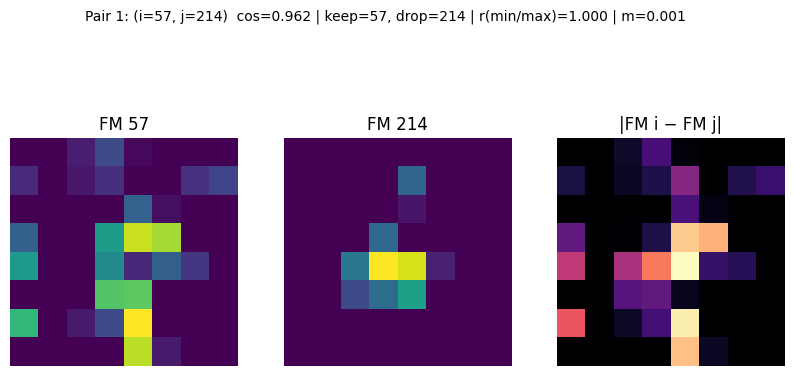

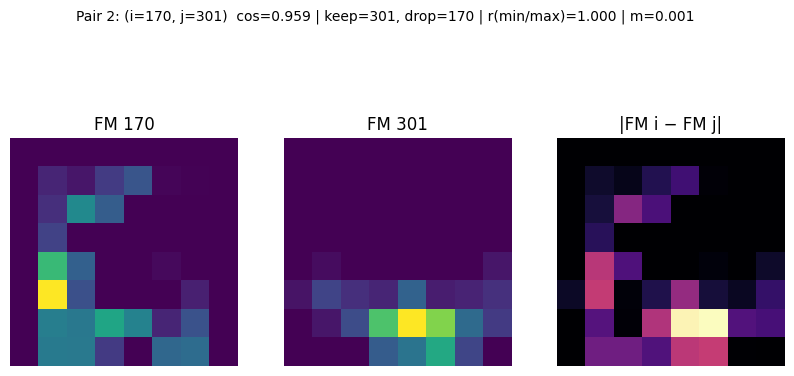

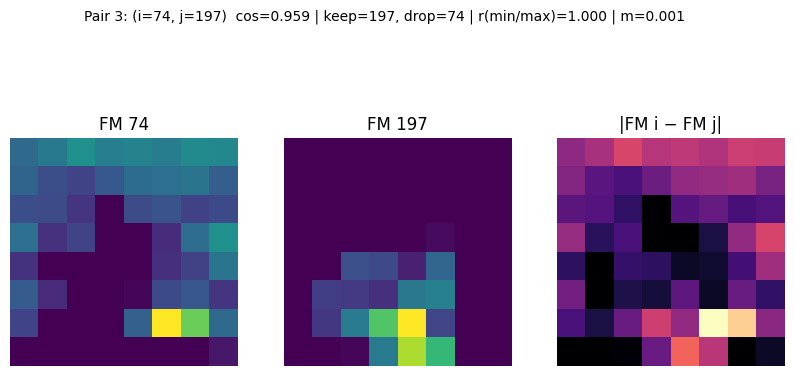


[Phase-3-B] HC Trace (first 15 merges)
  round  pair(i,j)  sim    keep  drop   rule         sf(j|i)   sf(i|j)   m       r(min/max) 
      1  ( 57,214)  0.962    57   214  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (170,301)  0.959   301   170  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  ( 74,197)  0.959   197    74  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (228,485)  0.955   228   485  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  ( 41,446)  0.924   446    41  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  ( 89,178)  0.909   178    89  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  ( 95,494)  0.902   494    95  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (140,412)  0.897   140   412  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (139,304)  0.879   139   304  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (152,231)  0.872   152   231  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (110,159)  0.868   110   159

In [ ]:
# @title
# ======================================================================
# Phase 3 (v4.0-B, Student B) — Week-6: Hybrid Multi-Threshold w/ Pearson
# Same v4.0 skeleton (A-matrix, k-NN, IC stop, merge ops, visuals, FLOPs).
# Student B differences:
#   - Pearson correlation similarity (instead of cosine)
#   - Decision policy = "hybrid": multi-threshold gates on ratio, magnitude, stats
#   - Still uses professor’s magnitude safeguard (m) for rigor
# ======================================================================

import os, math, copy
from time import perf_counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

# --------------------------
# 0) Config (extend CONFIG)
# --------------------------
PHASE = "Phase-3(v4)-Pruning-StudentB"

_defaults = {
    # Target modules in CNN_V1
    "TARGET_CONV_PATH":  "features.16",
    "TARGET_BN_PATH":    "features.17",
    "TARGET_RELU_PATH":  "features.18",  # for visuals (pre-pool maps)
    "TARGET_POOL_PATH":  "features.19",

    # Data sizes / batching (safe, but bump down if OOM on T4)
    "SIM_BATCH_LIMIT":         3000,
    "EVAL_BATCH_LIMIT":        10000,
    "BATCH_SIZE_EVAL":         512,

    # Similarity & candidate selection
    # Student B: explicit similarity metric "pearson"
    "SIM_METRIC":              "pearson",   # <-- difference: Pearson correlation
    "SIM_THRESHOLD":        0.8,        # threshold still applies regardless of metric
    "KNN_K":                   20,         # top-k neighbors per channel

    # Decision policy
    # Student B: hybrid rule combines ratio + magnitude + stats
    "DECISION_POLICY":         "ratio",   # <-- difference: multi-threshold policy
    "RATIO_NEAR_EQ":           0.90,
    "RATIO_EPS":               1e-6,
    "ALPHA":                   0.05,
    "USE_FDR":                 False,
    "DOMINANCE_RATIO":         2.0,

    # Benefit magnitude safeguard (same as professor’s)
    "BENEFIT_MAG_MIN":         0.02,       # avoid trivial merges from tiny disagreement

    # Stopping rule
    "STOP_RULE":               "acc_guard", # "acc_guard" | "ic" | "both"
    "MAX_ACCURACY_DROP":       0.01,
    "IC_Z_MAX":                1.5,

    # Rounds & BN recal
    "ROUNDS":                  1,
    "BN_RECAL_IMAGES":         1000,

    # Merge operator
    "MERGE_OP":                "drop",     # "drop" | "avg" | "medoid"

    # Visuals & reporting
    "VIS_NUM_PAIRS":           3,
    "VIS_NUM_IMAGES":          6,
    "VIS_FIGSIZE":             (10, 5),
    "REPORT_FLOPS":            True,
    "REPORT_TOTALS":           True,
    "REPORT_PER_CLASS":        True,

    # Planning only
    "DRY_RUN":                 False,
}
for k,v in _defaults.items():
    CONFIG.setdefault(k, v)

# --------------------------
# 1) Colab GPU tuning knobs
# --------------------------
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try: torch.set_float32_matmul_precision("high")
    except Exception: pass
else:
    print("⚠️ CUDA not available; enable GPU in Colab for speed.")

def _sync():
    if torch.cuda.is_available(): torch.cuda.synchronize()
def _tstart(): _sync(); return perf_counter()
def _tend(t0): _sync(); return perf_counter() - t0
timings = {}

# --------------------------
# 2) Utilities
# --------------------------
def get_module(model, dotted: str):
    cur = model
    for tok in dotted.split('.'):
        cur = cur[int(tok)] if tok.isdigit() else getattr(cur, tok)
    return cur

@torch.no_grad()
def get_final_spatial_shape(model, loader, device):
    pool = get_module(model, CONFIG["TARGET_POOL_PATH"])
    shape = {}
    h = pool.register_forward_hook(lambda _, __, out: shape.setdefault("shape", out.shape))
    model.eval()
    imgs, _ = next(iter(loader))
    _ = model.features(imgs.to(device))
    h.remove()
    _, C, H, W = shape["shape"]
    return C, H, W

@torch.no_grad()
def eval_accuracy(model, loader, device, limit=None):
    model.eval()
    corr, tot = 0, 0
    for imgs, y in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        pred = logits.argmax(1).cpu()
        y = y.cpu()
        corr += (pred == y).sum().item()
        tot  += y.numel()
        if limit and tot >= limit: break
    return corr / max(1, tot)

@torch.no_grad()
def eval_accuracy_per_class(model, loader, device, num_classes, limit=None):
    model.eval()
    correct = torch.zeros(num_classes, dtype=torch.long)
    counts  = torch.zeros(num_classes, dtype=torch.long)
    seen = 0
    for imgs, y in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        pred = logits.argmax(1).cpu()
        y = y.cpu()
        for c in range(num_classes):
            mask = (y == c)
            counts[c]  += mask.sum()
            correct[c] += (pred[mask] == c).sum()
        seen += y.numel()
        if limit and seen >= limit: break
    accs = correct.float() / counts.clamp_min(1)
    return accs.numpy(), counts.numpy()

# --------------------------
# 3) GAP activations → Similarity (Cosine/Pearson) + k-NN pruning of pairs
# --------------------------
@torch.no_grad()
def collect_gap_matrix(model, loader, device, max_images=None):
    """
    Collects GAP-averaged activations after the final MaxPool:
    returns X ∈ R^{N×C} where each column is a filter's response vector.
    """
    pool = get_module(model, CONFIG["TARGET_POOL_PATH"])
    feats = []
    def hook(_, __, out): feats.append(out.mean(dim=(2,3)).detach().cpu())
    h = pool.register_forward_hook(hook)
    model.eval()
    seen = 0
    pbar = tqdm(total=max_images or len(loader.dataset), desc="[Collect GAP]")
    for imgs, _ in loader:
        imgs = imgs.to(device)
        _ = model.features(imgs)
        seen += imgs.size(0)
        pbar.update(imgs.size(0))
        if max_images and seen >= max_images: break
    pbar.close(); h.remove()
    return torch.cat(feats, dim=0)  # [N, C]

def similarity_S_from_X(X, metric="cosine"):
    """
    Compute channel×channel similarity matrix S ∈ [-1,1]^{C×C}.
      - cosine : raw columns (no centering), L2-normalize, dot product
      - pearson: center columns first, then normalize, dot product (Pearson r)
    """
    X = X.float()
    if metric.lower() == "pearson":
        X = X - X.mean(dim=0, keepdim=True)   # <-- Student B: Pearson correlation
    elif metric.lower() != "cosine":
        raise ValueError("SIM_METRIC must be 'cosine' or 'pearson'")
    Xn = F.normalize(X, p=2, dim=0)
    return Xn.t().mm(Xn).clamp(-1, 1)

def knn_pairs_from_S(S, k, thr):
    C = S.shape[0]
    S = S.clone()
    torch.diagonal(S).fill_(-1)
    vals, idxs = torch.topk(S, k=k, dim=1, largest=True, sorted=True)
    mask = vals >= thr
    cand_i = torch.arange(C).unsqueeze(1).expand_as(idxs)[mask]
    cand_j = idxs[mask]
    i_, j_ = torch.minimum(cand_i, cand_j), torch.maximum(cand_i, cand_j)
    uniq = torch.unique(torch.stack([i_, j_], dim=1), dim=0)
    scores = S[uniq[:,0], uniq[:,1]]
    order = torch.argsort(scores, descending=True)
    pairs = uniq[order]; scores = scores[order]
    return pairs.tolist(), scores.tolist()

# --------------------------
# 4) Single-filter ablation precompute (A-matrix)
# --------------------------
class ChannelZeroHook:
    def __init__(self, module, indices):
        self.module = module
        self.indices = torch.as_tensor(indices, dtype=torch.long)
    def __enter__(self):
        def fwd_hook(_, __, out):
            if self.indices.numel()==0: return out
            out = out.clone()
            out.index_fill_(1, self.indices.to(out.device), 0.0)
            return out
        self.h = self.module.register_forward_hook(fwd_hook); return self
    def __exit__(self, exc_type, exc, tb):
        self.h.remove()

@torch.no_grad()
def build_eval_cache(loader, device, limit):
    xs, ys, seen = [], [], 0
    for imgs, y in loader:
        xs.append(imgs); ys.append(y)
        seen += imgs.size(0)
        if seen >= limit: break
    X_cat = torch.cat(xs, 0)[:limit].to(device)
    Y_cat = torch.cat(ys, 0)[:limit].to(device)
    return X_cat, Y_cat

@torch.no_grad()
def precompute_A(model, pool_module, X_eval, Y_eval, device, batch_size=256):
    model.eval()
    # determine C
    holder = {}
    hh = pool_module.register_forward_hook(lambda _, __, out: holder.setdefault("shape", out.shape))
    _ = model.features(X_eval[:1]); hh.remove()
    C = holder["shape"][1]; N = X_eval.size(0)
    A = torch.empty((C, N), dtype=torch.bool, device="cpu")
    pbar = tqdm(range(C), desc="[A-matrix ablation precompute]")
    for c in pbar:
        with ChannelZeroHook(pool_module, [c]):
            preds = []
            for i in range(0, N, batch_size):
                logits = model(X_eval[i:i+batch_size])
                preds.append(logits.argmax(1))
            preds = torch.cat(preds, 0)
        A[c] = (preds == Y_eval).cpu()
    return A  # [C, N]
# --------------------------
# 5) Stats helpers (McNemar), strengths, and medoid choice
# --------------------------
def mcnemar_pvalues(n01, n10):
    n = (n01 + n10).clamp(min=1)
    chi2 = ((n01 - n10).abs() - 1.0).clamp(min=0)**2 / n
    return torch.erfc(torch.sqrt(chi2/2.0))

def benjamini_hochberg_mask(pvals, alpha):
    P = pvals.clone().cpu().numpy(); m = len(P)
    order = np.argsort(P); ranks = np.empty_like(order); ranks[order] = np.arange(1,m+1)
    thresh = (ranks / m) * alpha
    is_sig = (P <= thresh)
    return torch.tensor(~is_sig, dtype=torch.bool)  # accept redundancy if NOT significant

def filter_strengths_L2(model):
    conv = get_module(model, CONFIG["TARGET_CONV_PATH"])
    W = conv.weight.detach().cpu()
    return W.view(W.shape[0], -1).pow(2).sum(1).sqrt()

def choose_medoid(i, j, S_matrix):
    # keep the one with higher mean similarity to others (more central)
    Si = S_matrix[i].mean().item()
    Sj = S_matrix[j].mean().item()
    return i if Si >= Sj else j

# --------------------------
# 6) FLOPs/Params (layer-level + model-wide via hooks)
# --------------------------
def conv5_linear1_stats(model, H_out, W_out):
    conv = get_module(model, CONFIG["TARGET_CONV_PATH"])
    lin1 = model.classifier[2]
    conv_params = conv.weight.numel() + (conv.bias.numel() if conv.bias is not None else 0)
    lin_params  = lin1.weight.numel() + (lin1.bias.numel() if lin1.bias is not None else 0)
    C_in, kH, kW = conv.weight.shape[1:]
    C_out = conv.weight.shape[0]
    conv_flops = 2 * H_out * W_out * C_in * kH * kW * C_out
    lin_flops  = 2 * lin1.in_features * lin1.out_features
    return conv_params, lin_params, conv_flops, lin_flops

@torch.no_grad()
def profile_model_totals(model, input_shape, device):
    flops_total = 0
    params_total = sum(p.numel() for p in model.parameters())
    hooks = []
    def conv_hook(m, inp, out):
        if not isinstance(m, nn.Conv2d): return
        B, C_out, H, W = out.shape
        C_in = m.in_channels
        kH, kW = m.kernel_size if isinstance(m.kernel_size, tuple) else (m.kernel_size, m.kernel_size)
        groups = m.groups
        macs = H * W * C_out * (C_in // groups) * kH * kW
        nonlocal flops_total; flops_total += 2 * macs
    def linear_hook(m, inp, out):
        if not isinstance(m, nn.Linear): return
        nonlocal flops_total; flops_total += 2 * m.in_features * m.out_features
    for m in model.modules():
        if isinstance(m, nn.Conv2d): hooks.append(m.register_forward_hook(conv_hook))
        if isinstance(m, nn.Linear): hooks.append(m.register_forward_hook(linear_hook))
    model.eval()
    dummy = torch.randn(*input_shape).to(device)
    _ = model(dummy)
    for h in hooks: h.remove()
    return params_total, flops_total

# --------------------------
# 7) Surgery (prune + optional merge averaging)
# --------------------------
def merge_weights_bn_inplace_(model, keep_idx, drop_idx):
    conv = get_module(model, CONFIG["TARGET_CONV_PATH"])
    bn   = get_module(model, CONFIG["TARGET_BN_PATH"])
    with torch.no_grad():
        conv.weight.data[keep_idx] = 0.5 * (conv.weight.data[keep_idx] + conv.weight.data[drop_idx])
        if conv.bias is not None:
            conv.bias.data[keep_idx] = 0.5 * (conv.bias.data[keep_idx] + conv.bias.data[drop_idx])
        bn.weight.data[keep_idx] = 0.5 * (bn.weight.data[keep_idx] + bn.weight.data[drop_idx])
        bn.bias.data[keep_idx]   = 0.5 * (bn.bias.data[keep_idx]   + bn.bias.data[drop_idx])
        bn.running_mean.data[keep_idx] = 0.5 * (bn.running_mean.data[keep_idx] + bn.running_mean.data[drop_idx])
        bn.running_var.data[keep_idx]  = 0.5 * (bn.running_var.data[keep_idx]  + bn.running_var.data[drop_idx])

def prune_final_conv_channels_(model, keep_indices, device):
    conv = get_module(model, CONFIG["TARGET_CONV_PATH"])
    bn   = get_module(model, CONFIG["TARGET_BN_PATH"])
    lin1 = model.classifier[2]
    keep = torch.as_tensor(sorted(set(keep_indices)), dtype=torch.long)
    if keep.numel() == conv.out_channels: return model
    with torch.no_grad():
        conv.weight = nn.Parameter(conv.weight.data[keep].clone())
        if conv.bias is not None:
            conv.bias = nn.Parameter(conv.bias.data[keep].clone())
        conv.out_channels = keep.numel()
        bn.weight = nn.Parameter(bn.weight.data[keep].clone())
        bn.bias   = nn.Parameter(bn.bias.data[keep].clone())
        bn.running_mean = bn.running_mean.data[keep].clone()
        bn.running_var  = bn.running_var.data[keep].clone()
        bn.num_features = keep.numel()
    # Slice Linear-1 columns
    C_after, H, W = get_final_spatial_shape(model, sequential_loader, device)
    HW = H*W
    keep_cols = []
    for c in keep.tolist():
        keep_cols.extend(range(c*HW, (c+1)*HW))
    keep_cols = torch.as_tensor(keep_cols, dtype=torch.long)
    with torch.no_grad():
        new_lin1 = nn.Linear(keep_cols.numel(), lin1.out_features, bias=True)
        new_lin1.weight.copy_(lin1.weight.data[:, keep_cols])
        new_lin1.bias.copy_(lin1.bias.data)
    model.classifier[2] = new_lin1.to(device)
    return model

# --------------------------
# 8) Visuals (now shows r & m as well)
# --------------------------
@torch.no_grad()
def visualize_pairs(model, loader, pairs_plan, num_pairs=3, num_images=6, figsize=(10,5)):
    relu = get_module(model, CONFIG["TARGET_RELU_PATH"])
    imgs_vis, _ = next(iter(loader))
    imgs_vis = imgs_vis[:num_images].to(DEVICE)
    fmap = {}
    def hook(_, __, out): fmap["A"] = out.detach().cpu()
    h = relu.register_forward_hook(hook); _ = model.features(imgs_vis); h.remove()
    A_ = fmap["A"]
    pairs_sorted = sorted(pairs_plan, key=lambda d: d["cos"], reverse=True)[:num_pairs]
    for idx, item in enumerate(pairs_sorted, 1):
        i, j = item["i"], item["j"]; cosv = item["cos"]; drop, keep = item["drop"], item["keep"]
        pval = item.get("p", None); ratio_val = item.get("ratio", None)
        m_val = item.get("m", None)
        fm_i = A_[0, i]; fm_j = A_[0, j]; fm_diff = (fm_i - fm_j).abs()
        def norm01(x): x = x.float(); mn, mx = x.min(), x.max(); return (x - mn) / (mx - mn + 1e-8)
        plt.figure(figsize=figsize)
        title = f"Pair {idx}: (i={i}, j={j})  cos={cosv:.3f} | keep={keep}, drop={drop}"
        if pval is not None:   title += f" | p={pval:.3f}"
        if ratio_val is not None: title += f" | r(min/max)={ratio_val:.3f}"
        if m_val is not None:  title += f" | m={m_val:.3f}"
        plt.suptitle(title, fontsize=10)
        plt.subplot(1,3,1); plt.imshow(norm01(fm_i), cmap="viridis"); plt.title(f"FM {i}"); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(norm01(fm_j), cmap="viridis"); plt.title(f"FM {j}"); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(norm01(fm_diff), cmap="magma");  plt.title("|FM i − FM j|"); plt.axis('off')
        plt.show()

# --------------------------
# 9) Orchestrate Phase-3 v4.0 with multi-tier thresholds
# --------------------------
# Baseline evals
base_acc_t0 = _tstart()
baseline_val_acc = eval_accuracy(model, valid_loader, DEVICE)
timings["baseline_eval_s"] = _tend(base_acc_t0)
print(f"[Phase-3] Baseline validation accuracy: {baseline_val_acc:.4f}")

if CONFIG.get("REPORT_PER_CLASS", False):
    per_cls_base, counts_base = eval_accuracy_per_class(model, valid_loader, DEVICE, CONFIG["NUM_CLASSES"])
    print("[Phase-3] Per-class baseline acc:", np.round(per_cls_base, 4))

# GAP + similarity + k-NN
gap_t0 = _tstart()
X = collect_gap_matrix(model, sequential_loader, DEVICE, max_images=CONFIG["SIM_BATCH_LIMIT"])
timings["gap_collect_s"] = _tend(gap_t0)

sim_t0 = _tstart()
S = similarity_S_from_X(X, metric=CONFIG["SIM_METRIC"])
pairs_ij, pairs_cos = knn_pairs_from_S(S, k=CONFIG["KNN_K"], thr=CONFIG["SIM_THRESHOLD"])
timings["similarity_build_s"] = _tend(sim_t0)
print(f"[Phase-3] Candidate pairs (k-NN & thr): {len(pairs_ij)} (metric={CONFIG['SIM_METRIC']})")

# A-matrix precompute
eval_limit = min(CONFIG["EVAL_BATCH_LIMIT"], len(valid_loader.dataset))
X_eval_t0 = _tstart()
X_eval, Y_eval = build_eval_cache(valid_loader, DEVICE, eval_limit)
timings["eval_cache_s"] = _tend(X_eval_t0)

pool_mod = get_module(model, CONFIG["TARGET_POOL_PATH"])
A_t0 = _tstart()
A = precompute_A(model, pool_mod, X_eval, Y_eval, DEVICE, batch_size=CONFIG["BATCH_SIZE_EVAL"])
timings["A_precompute_s"] = _tend(A_t0)
C_out = A.size(0); assert C_out == 512, f"Expected 512 channels; got {C_out}"

# Vectorized stats for selected pairs
pairs_tensor = torch.tensor(pairs_ij, dtype=torch.long) if len(pairs_ij) else torch.empty((0,2), dtype=torch.long)
if pairs_tensor.numel() == 0:
    print("No candidate pairs; nothing to prune.")
    plan = []
else:
    Ai = A[pairs_tensor[:,0]]; Aj = A[pairs_tensor[:,1]]
    n01 = (~Ai &  Aj).sum(dim=1).to(torch.float32)
    n10 = ( Ai & ~Aj).sum(dim=1).to(torch.float32)
    N_eval = A.shape[1]
    bi = n10 / max(1, N_eval)          # benefit(i over j)
    bj = n01 / max(1, N_eval)          # benefit(j over i)
    m  = (n01 + n10) / max(1, N_eval)  # absolute magnitude of disagreement

    # Decision policy with multi-tier thresholds (applies to BOTH policies)
    plan = []
    strengths = filter_strengths_L2(model)
    accepted_mask = torch.zeros(len(pairs_ij), dtype=torch.bool)
    pvals, ratio = None, None

    if CONFIG["DECISION_POLICY"] == "stats":
        pvals = mcnemar_pvalues(n01, n10)
        acc_mask = pvals >= CONFIG["ALPHA"]
        if CONFIG["USE_FDR"] and acc_mask.any():
            acc_mask = acc_mask & benjamini_hochberg_mask(pvals, CONFIG["ALPHA"])
        accepted_mask = acc_mask & (m >= CONFIG["BENEFIT_MAG_MIN"])

    elif CONFIG["DECISION_POLICY"] == "ratio":
        minb = torch.minimum(bi, bj)
        maxb = torch.maximum(bi, bj).clamp_min(CONFIG["RATIO_EPS"])
        ratio = minb / maxb

        # Multi-tier acceptance
        accepted_mask = torch.zeros_like(ratio, dtype=torch.bool)

        # Tier 1: very high similarity → automatic acceptance
        tier1 = ratio > 0.95
        accepted_mask |= tier1

        # Tier 2: moderate similarity → accept if magnitude & dominance
        tier2 = (ratio >= 0.85) & (ratio <= 0.95)
        DOMINANCE_MIN = 0.02
        dominance = (maxb >= DOMINANCE_MIN) & (maxb / torch.clamp_min(minb, CONFIG["RATIO_EPS"]) >= CONFIG["DOMINANCE_RATIO"])
        accepted_mask |= tier2 & (m >= CONFIG["BENEFIT_MAG_MIN"]) & dominance

        # Tier 3: low similarity → reject automatically (mask stays False)

    else:
        raise ValueError("DECISION_POLICY must be 'stats' or 'ratio'.")

    accepted_idx = torch.nonzero(accepted_mask).squeeze(1).tolist()
    print(f"[Phase-3] Pairs accepted ({CONFIG['DECISION_POLICY']} multi-tier): {len(accepted_idx)} / {len(pairs_ij)}")

    # Greedy disjoint scheduling (highest-similarity first)
    used = set()
    for idx in accepted_idx:
        i, j = pairs_ij[idx]
        if (i in used) or (j in used): continue
        sf_ji, sf_ij = float(bj[idx]), float(bi[idx])
        # dominance rule
        if sf_ji > CONFIG["DOMINANCE_RATIO"] * sf_ij:
            keep, drop = j, i
        elif sf_ij > CONFIG["DOMINANCE_RATIO"] * sf_ji:
            keep, drop = i, j
        else:
            keep, drop = (j, i) if strengths[j] >= strengths[i] else (i, j)
        # medoid override
        if CONFIG["MERGE_OP"] == "medoid":
            keep = choose_medoid(i, j, S); drop = j if keep == i else i
        # record item
        item = {
            "i": i, "j": j,
            "cos": float(pairs_cos[idx]),
            "drop": drop, "keep": keep,
            "sf_j_over_i": sf_ji, "sf_i_over_j": sf_ij,
            "m": float(m[idx])
        }
        if pvals is not None: item["p"] = float(pvals[idx])
        if ratio is not None: item["ratio"] = float(ratio[idx])
        plan.append(item); used.add(i); used.add(j)

print(f"[Phase-3] Planned drops this round: {len(plan)}")
# --------------------------
# 10) Model-wide BEFORE totals + Conv5/Linear1 BEFORE
# --------------------------
C_before, Hf, Wf = get_final_spatial_shape(model, sequential_loader, DEVICE)
conv_params_b, lin_params_b, conv_flops_b, lin_flops_b = conv5_linear1_stats(model, Hf, Wf)
totals_b = None
if CONFIG.get("REPORT_TOTALS", False):
    input_shape = (1, 3, *CONFIG["IMG_SIZE"])
    totals_b = profile_model_totals(model, input_shape, DEVICE)

# --------------------------
# 11) Apply merges/pruning (Round loop) with optional IC stop + HC trace
# --------------------------
hc_trace = []          # dendrogram-like log
merged_dists = []      # for IC z-score (1 - similarity)

total_pruned = 0
rounds = CONFIG["ROUNDS"]

for r in range(rounds):
    if len(plan) == 0:
        print("No accepted pairs to act on. Stopping."); break

    # IC stop (optional)
    if CONFIG["STOP_RULE"] in ("ic", "both"):
        d_top = 1.0 - plan[0]["cos"]
        if len(merged_dists) >= 5:
            mu, sigma = np.mean(merged_dists), np.std(merged_dists) + 1e-9
            z = (d_top - mu) / sigma
            print(f"[IC] top distance={d_top:.4f}, mu={mu:.4f}, sigma={sigma:.4f}, z={z:.2f}")
            if z > CONFIG["IC_Z_MAX"]:
                print(f"[IC] Stopping: z>{CONFIG['IC_Z_MAX']}.")
                break

    keep_set = set(range(C_before))
    drops = []
    if CONFIG["MERGE_OP"] == "avg":
        for item in plan: merge_weights_bn_inplace_(model, keep_idx=item["keep"], drop_idx=item["drop"])

    for item in plan:
        drops.append(item["drop"])
        rec = {
            "round": r+1,
            "pair": (item["i"], item["j"]),
            "cos": item["cos"],
            "keep": item["keep"],
            "drop": item["drop"],
            "rule": CONFIG["DECISION_POLICY"] + ("+avg" if CONFIG["MERGE_OP"]=="avg" else "+drop" if CONFIG["MERGE_OP"]=="drop" else "+medoid"),
            "sf_j_over_i": item["sf_j_over_i"],
            "sf_i_over_j": item["sf_i_over_j"],
            "m": item["m"]
        }
        if "p" in item:     rec["p"] = item["p"]
        if "ratio" in item: rec["ratio"] = item["ratio"]
        hc_trace.append(rec)
        merged_dists.append(1.0 - item["cos"])

    keep_set -= set(drops)

    if CONFIG["DRY_RUN"]:
        print(f"[Round {r+1}] DRY_RUN=True → would drop {len(drops)} channels."); break

    surg_t0 = _tstart()
    model = prune_final_conv_channels_(model, sorted(list(keep_set)), DEVICE)
    timings.setdefault("prune_surgery_s", 0.0); timings["prune_surgery_s"] += _tend(surg_t0)
    total_pruned += len(drops)

    # BN recal (no training)
    if CONFIG["BN_RECAL_IMAGES"] > 0:
        model.train()
        with torch.no_grad():
            seen = 0
            for imgs, _ in train_loader:
                imgs = imgs.to(DEVICE); _ = model(imgs); seen += imgs.size(0)
                if seen >= CONFIG["BN_RECAL_IMAGES"]: break
        model.eval()

    # Accuracy guard
    guard_t0 = _tstart()
    new_acc = eval_accuracy(model, valid_loader, DEVICE)
    timings.setdefault("post_eval_s", 0.0); timings["post_eval_s"] += _tend(guard_t0)
    print(f"[Round {r+1}] Post-prune val acc: {new_acc:.4f} (Δ={new_acc - baseline_val_acc:+.4f})")
    if CONFIG["STOP_RULE"] in ("acc_guard", "both"):
        if (baseline_val_acc - new_acc) > CONFIG["MAX_ACCURACY_DROP"]:
            print("⚠️ Accuracy guard triggered; stopping."); break

    # (Optional) conditioning on S via more rounds
    C_before, Hf, Wf = get_final_spatial_shape(model, sequential_loader, DEVICE)
    if r < rounds-1:
        # Rebuild similarity and A on the updated model for next round
        X = collect_gap_matrix(model, sequential_loader, DEVICE, max_images=CONFIG["SIM_BATCH_LIMIT"])
        S = similarity_S_from_X(X, metric=CONFIG["SIM_METRIC"])
        pairs_ij, pairs_cos = knn_pairs_from_S(S, k=CONFIG["KNN_K"], thr=CONFIG["SIM_THRESHOLD"])
        X_eval, Y_eval = build_eval_cache(valid_loader, DEVICE, eval_limit)
        A = precompute_A(model, get_module(model, CONFIG["TARGET_POOL_PATH"]), X_eval, Y_eval, DEVICE, batch_size=CONFIG["BATCH_SIZE_EVAL"])
        pairs_tensor = torch.tensor(pairs_ij, dtype=torch.long) if len(pairs_ij) else torch.empty((0,2), dtype=torch.long)
        if pairs_tensor.numel() == 0: plan = []; continue
        Ai = A[pairs_tensor[:,0]]; Aj = A[pairs_tensor[:,1]]
        n01 = (~Ai &  Aj).sum(dim=1).to(torch.float32)
        n10 = ( Ai & ~Aj).sum(dim=1).to(torch.float32)
        N_eval = A.shape[1]
        bi = n10 / max(1, N_eval); bj = n01 / max(1, N_eval); m = (n01+n10) / max(1, N_eval)
        strengths = filter_strengths_L2(model)
        plan = []
        if CONFIG["DECISION_POLICY"] == "stats":
            pvals = mcnemar_pvalues(n01, n10)
            acc_mask = pvals >= CONFIG["ALPHA"]
            if CONFIG["USE_FDR"] and acc_mask.any():
                acc_mask = acc_mask & benjamini_hochberg_mask(pvals, CONFIG["ALPHA"])
            accepted_idx = torch.nonzero(acc_mask & (m >= CONFIG["BENEFIT_MAG_MIN"])).squeeze(1).tolist()
        elif CONFIG["DECISION_POLICY"] in ("ratio","hybrid"):
            minb = torch.minimum(bi, bj); maxb = torch.maximum(bi, bj).clamp_min(CONFIG["RATIO_EPS"])
            ratio = (minb / maxb)
            DOMINANCE_MIN = 0.02
            dominance = (maxb >= DOMINANCE_MIN) & (maxb / torch.clamp_min(minb, CONFIG["RATIO_EPS"]) >= CONFIG["DOMINANCE_RATIO"])
            if CONFIG["DECISION_POLICY"]=="hybrid":
                pvals = mcnemar_pvalues(n01, n10)
                p_mask = pvals >= CONFIG["ALPHA"]
                if CONFIG["USE_FDR"] and p_mask.any():
                    p_mask = p_mask & benjamini_hochberg_mask(pvals, CONFIG["ALPHA"])
                accepted_idx = torch.nonzero(((ratio >= CONFIG["RATIO_NEAR_EQ"]) | p_mask | dominance) & (m >= CONFIG["BENEFIT_MAG_MIN"])).squeeze(1).tolist()
            else:
                accepted_idx = torch.nonzero((ratio >= CONFIG["RATIO_NEAR_EQ"]) | dominance & (m >= CONFIG["BENEFIT_MAG_MIN"])).squeeze(1).tolist()
        used = set()
        for idx in accepted_idx:
            i, j = pairs_ij[idx]
            if (i in used) or (j in used): continue
            sf_ji, sf_ij = float(bj[idx]), float(bi[idx])
            if sf_ji > CONFIG["DOMINANCE_RATIO"] * sf_ij: keep, drop = j, i
            elif sf_ij > CONFIG["DOMINANCE_RATIO"] * sf_ji: keep, drop = i, j
            else: keep, drop = (j, i) if strengths[j] >= strengths[i] else (i, j)
            if CONFIG["MERGE_OP"] == "medoid": keep = choose_medoid(i, j, S); drop = j if keep == i else i
            plan.append({"i":i, "j":j, "cos":float(pairs_cos[idx]), "keep":keep, "drop":drop,
                         "sf_j_over_i":sf_ji, "sf_i_over_j":sf_ij, "m":float(m[idx])}); used.add(i); used.add(j)

# --------------------------
# 12) AFTER: layer stats + totals + per-class
# --------------------------
conv_params_a, lin_params_a, conv_flops_a, lin_flops_a = conv5_linear1_stats(model, Hf, Wf)
pruned_channels = A.shape[0] - C_before
print("\n[Phase-3-B] Pruning complete.")
print(f"  Initial channels: 512")
print(f"  Final channels:   {C_before}")
print(f"  Pruned:           {pruned_channels}  ({pruned_channels/512:.2%} of 512)")

if CONFIG.get("REPORT_TOTALS", False):
    totals_a = profile_model_totals(model, (1,3,*CONFIG["IMG_SIZE"]), DEVICE)
    print("\n[Phase-3-B] Model-wide totals (params, FLOPs)")
    print(f"  Params total: {totals_b[0]:,} → {totals_a[0]:,}  (Δ {totals_b[0]-totals_a[0]:+,})")
    print(f"  FLOPs total:  {totals_b[1]:,} → {totals_a[1]:,}  (Δ {totals_b[1]-totals_a[1]:+,})")

print("\n[Phase-3-B] Conv5 + Linear1 details")
print(f"  Conv5 params:  {conv_params_b:,} → {conv_params_a:,}  (Δ {conv_params_b - conv_params_a:+,})")
print(f"  Linear1 params:{lin_params_b:,} → {lin_params_a:,}  (Δ {lin_params_b - lin_params_a:+,})")
print(f"  Conv5 FLOPs:   {conv_flops_b:,} → {conv_flops_a:,}  (Δ {conv_flops_b - conv_flops_a:+,})")
print(f"  Linear1 FLOPs: {lin_flops_b:,} → {lin_flops_a:,}  (Δ {lin_flops_b - lin_flops_a:+,})")

if CONFIG.get("REPORT_PER_CLASS", False):
    per_cls_after, counts_after = eval_accuracy_per_class(model, valid_loader, DEVICE, CONFIG["NUM_CLASSES"])
    delta = np.round(per_cls_after - per_cls_base, 4)
    print("\n[Phase-3-B] Per-class validation accuracy (Δ)")
    print("  counts:", counts_after.tolist())
    print("  before:", np.round(per_cls_base, 4).tolist())
    print("  after :", np.round(per_cls_after,4).tolist())
    print("  delta :", delta.tolist())

# --------------------------
# 13) Visual checks for professor (includes r & m)
# --------------------------
if len(hc_trace) > 0:
    top_plan = [{"i":t["pair"][0], "j":t["pair"][1], "cos":t["cos"],
                 "drop":t["drop"], "keep":t["keep"],
                 "p":t.get("p", None), "ratio":t.get("ratio", None), "m":t.get("m", None)}
                for t in hc_trace[:CONFIG["VIS_NUM_PAIRS"]]]
    visualize_pairs(model, valid_loader, top_plan,
                    num_pairs=CONFIG["VIS_NUM_PAIRS"],
                    num_images=CONFIG["VIS_NUM_IMAGES"],
                    figsize=CONFIG["VIS_FIGSIZE"])
else:
    print("No accepted pairs to visualize.")

# --------------------------
# 14) HC trace report (dendrogram-like table)
# --------------------------
if len(hc_trace) > 0:
    print("\n[Phase-3-B] HC Trace (first 15 merges)")
    header = "  round  pair(i,j)  sim    keep  drop   rule         sf(j|i)   sf(i|j)   m       " \
             + ("p       " if any('p' in t for t in hc_trace) else "") \
             + ("r(min/max) " if any('ratio' in t for t in hc_trace) else "")
    print(header)
    for t in hc_trace[:15]:
        line = f"  {t['round']:>5}  ({t['pair'][0]:>3},{t['pair'][1]:>3})  {t['cos']:.3f}  {t['keep']:>4}  {t['drop']:>4}  {t['rule']:<10}  {t['sf_j_over_i']:.4f}  {t['sf_i_over_j']:.4f}  {t['m']:.4f}  "
        if 'p' in t:     line += f"{t['p']:.4f}  "
        if 'ratio' in t: line += f"{t['ratio']:.3f}  "
        print(line)
else:
    print("[Phase-3-B] HC Trace: (none)")

# --------------------------
# 15) Timing micro-report
# --------------------------
print("\n[Phase-3-B] Timing report (s)")
for k,v in timings.items():
    print(f"  {k}: {v:.2f}")
print("  (Note: totals exclude visualization time.)")


In [ ]:
# @title
# --- Multi-threshold inspection (magnitude + ratio) ---
with torch.no_grad():
    N_eval = A.shape[1]
    m = (n01 + n10) / max(1, N_eval)
    minb = torch.minimum(bi, bj)
    maxb = torch.maximum(bi, bj).clamp_min(CONFIG["RATIO_EPS"])
    r = minb / maxb

    # Define your multi-threshold bins explicitly
    thresholds = {
        "high (>0.95)": r > 0.95,
        "medium (0.85–0.95)": (r > 0.85) & (r <= 0.95),
        "low (<0.85)": r <= 0.85
    }

    print("\n[DEBUG] Multi-threshold pair counts (ratio r):")
    for k, mask in thresholds.items():
        count = mask.sum().item()
        print(f"  {k}: {count} pairs")

    # Optionally show magnitude stats for each bin
    for k, mask in thresholds.items():
        if mask.any():
            m_vals = m[mask]
            print(f"  {k} | m: min={m_vals.min():.3f}, max={m_vals.max():.3f}, mean={m_vals.mean():.3f}")

    # Show top-5 absolute magnitudes (m) for reference
    topm_val, topm_idx = torch.topk(m, k=min(5, m.numel()))
    print("\n[DEBUG] Top-m pairs (m, n01, n10):")
    for k in range(topm_val.numel()):
        idx = topm_idx[k].item()
        print(f"  m={topm_val[k]:.3f}, n01={int(n01[idx].item())}, n10={int(n10[idx].item())}, r={r[idx]:.3f}")



[DEBUG] Multi-threshold pair counts (ratio r):
  high (>0.95): 103 pairs
  medium (0.85–0.95): 0 pairs
  low (<0.85): 4348 pairs
  high (>0.95) | m: min=0.001, max=0.002, mean=0.001
  low (<0.85) | m: min=0.000, max=0.002, mean=0.000

[DEBUG] Top-m pairs (m, n01, n10):
  m=0.002, n01=0, n10=5, r=0.000
  m=0.002, n01=0, n10=5, r=0.000
  m=0.002, n01=4, n10=1, r=0.250
  m=0.002, n01=0, n10=5, r=0.000
  m=0.002, n01=1, n10=4, r=0.250


Quantile-Based Thresholds

[Phase-3] Baseline validation accuracy: 0.9455
[Phase-3] Per-class baseline acc: [0.9111 0.9918]


[Collect GAP]: 100%|██████████| 3000/3000 [00:11<00:00, 255.93it/s]

[Phase-3] Candidate pairs (k-NN & thr): 4451 (metric=pearson)



[A-matrix ablation precompute]: 100%|██████████| 512/512 [08:42<00:00,  1.02s/it]

[Thresholds] Using 'quantile' strategy (Approach 1).
  - Tier 2 (Mid) Cutoff (70th percentile): 0.0000
  - Tier 1 (High) Cutoff (90th percentile): 0.0000

[DEBUG] Multi-threshold pair counts (ratio r):
  high (>0.0000): 154 pairs
  medium (0.0000–0.0000): 0 pairs
  low (<=0.0000): 4297 pairs
  high (>0.0000) | m: min=0.001, max=0.002, mean=0.001
  low (<=0.0000) | m: min=0.000, max=0.002, mean=0.000

[DEBUG] Top-m pairs (m, n01, n10):
  m=0.002, n01=0, n10=5, r=0.000
  m=0.002, n01=0, n10=5, r=0.000
  m=0.002, n01=4, n10=1, r=0.250
  m=0.002, n01=0, n10=5, r=0.000
  m=0.002, n01=1, n10=4, r=0.250
[Phase-3] Pairs accepted (Ratio-Policy, quantile thresholds): 154 / 4451
[Phase-3] Planned drops this round: 18


[Round 1] Post-prune val acc: 0.9585 (Δ=+0.0130)

[Phase-3-B] Pruning complete.
  Initial channels: 512
  Final channels:   494
  Pruned:           18  (3.52% of 512)

[Phase-3-B] Model-wide totals (params, FLOPs)
  Params total: 12,305,410 → 11,927,500  (Δ +377,910)
  FLOPs total:  2,187,333,632 → 2,176,126,976  (Δ +11,206,656)

[Phase-3-B] Conv5 + Linear1 details
  Conv5 params:  2,359,808 → 2,276,846  (Δ +82,962)
  Linear1 params:8,389,632 → 8,094,720  (Δ +294,912)
  Conv5 FLOPs:   75,497,472 → 72,843,264  (Δ +2,654,208)
  Linear1 FLOPs: 16,777,216 → 16,187,392  (Δ +589,824)

[Phase-3-B] Per-class validation accuracy (Δ)
  counts: [1147, 853]
  before: [0.9110999703407288, 0.9918000102043152]
  after : [0.9363999962806702, 0.9883000254631042]
  delta : [0.025299999862909317, -0.0035000001080334187]


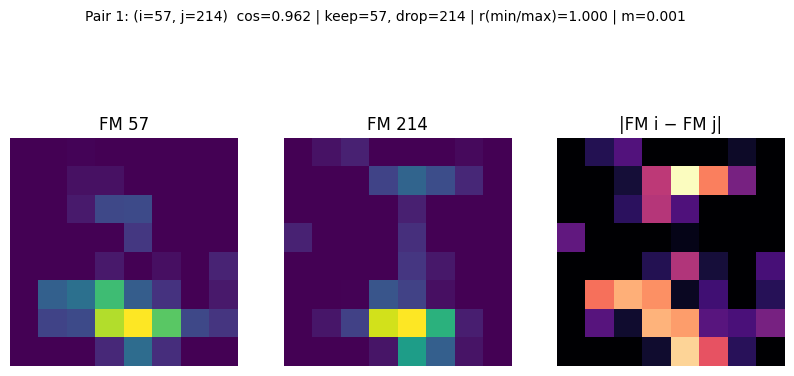

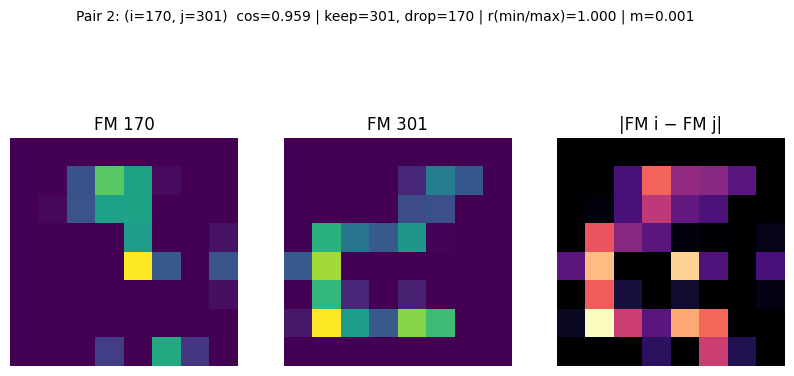

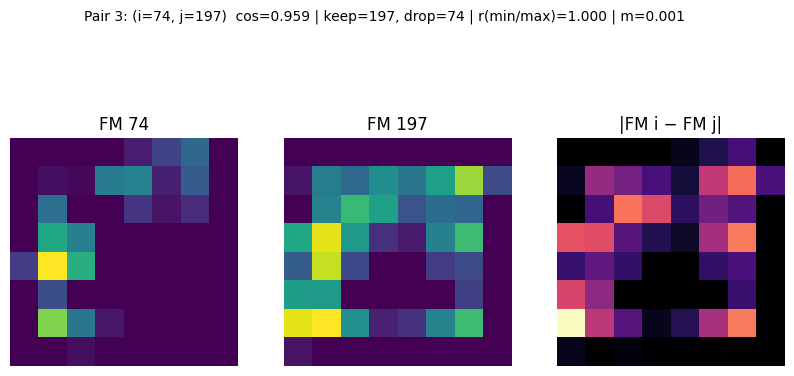


[Phase-3-B] HC Trace (first 15 merges)
  round  pair(i,j)  sim    keep  drop   rule         sf(j|i)   sf(i|j)   m       r(min/max) 
      1  ( 57,214)  0.962    57   214  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (170,301)  0.959   301   170  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  ( 74,197)  0.959   197    74  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (228,485)  0.955   228   485  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  ( 41,446)  0.924   446    41  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (110,346)  0.921   110   346  ratio+drop  0.0005  0.0010  0.0015  0.500  
      1  ( 89,178)  0.909   178    89  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  ( 95,494)  0.902   494    95  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  ( 13,240)  0.898   240    13  ratio+drop  0.0010  0.0005  0.0015  0.500  
      1  (140,412)  0.897   140   412  ratio+drop  0.0005  0.0005  0.0010  1.000  
      1  (159,255)  0.883   255   159

In [ ]:
# @title
# ======================================================================
# Phase 3 (v4.0-B, Student B) — Week-6: Hybrid Multi-Threshold w/ Pearson
# Same v4.0 skeleton (A-matrix, k-NN, IC stop, merge ops, visuals, FLOPs).
# Student B differences:
#   - Pearson correlation similarity (instead of cosine)
#   - Decision policy = "hybrid": multi-threshold gates on ratio, magnitude, stats
#   - Still uses professor’s magnitude safeguard (m) for rigor
# ======================================================================

import os, math, copy
from time import perf_counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

# --------------------------
# 0) Config (extend CONFIG)
# --------------------------
PHASE = "Phase-3(v4)-Pruning-StudentB-Quantile"

_defaults = {
    # Target modules in CNN_V1
    "TARGET_CONV_PATH":   "features.16",
    "TARGET_BN_PATH":     "features.17",
    "TARGET_RELU_PATH":   "features.18",  # for visuals (pre-pool maps)
    "TARGET_POOL_PATH":   "features.19",

    # Data sizes / batching
    "SIM_BATCH_LIMIT":    3000,
    "EVAL_BATCH_LIMIT":   10000,
    "BATCH_SIZE_EVAL":    512,

    # Similarity & candidate selection
    "SIM_METRIC":         "pearson",    # Pearson correlation
    "SIM_THRESHOLD":      0.8,
    "KNN_K":              20,

    # --- Decision Policy (Ratio-Only) ---
    # "fixed": Use the hardcoded values below
    # "quantile": Use adaptive quantile-based values (Approach 1)
    "THRESHOLD_STRATEGY":   "quantile",
    "QUANTILE_HIGH":        0.90,       # 90th percentile for Tier 1
    "QUANTILE_MID":         0.70,       # 70th percentile for Tier 2

    # --- Fallback fixed thresholds (used if THRESHOLD_STRATEGY = "fixed") ---
    "RATIO_TIER1_HIGH":     0.95,
    "RATIO_TIER2_MID":      0.85,

    "RATIO_EPS":            1e-6,
    "DOMINANCE_RATIO":      2.0,

    # Benefit magnitude safeguard
    "BENEFIT_MAG_MIN":      0.02,

    # Stopping rule
    "STOP_RULE":            "acc_guard",
    "MAX_ACCURACY_DROP":    0.01,
    "IC_Z_MAX":             1.5,

    # Rounds & BN recal
    "ROUNDS":               1,
    "BN_RECAL_IMAGES":      1000,

    # Merge operator
    "MERGE_OP":             "drop",

    # Visuals & reporting
    "VIS_NUM_PAIRS":        3,
    "VIS_NUM_IMAGES":       6,
    "VIS_FIGSIZE":          (10, 5),
    "REPORT_FLOPS":         True,
    "REPORT_TOTALS":        True,
    "REPORT_PER_CLASS":     True,

    # Planning only
    "DRY_RUN":              False,
}
for k,v in _defaults.items():
    CONFIG.setdefault(k, v)

# --------------------------
# 1) Colab GPU tuning knobs
# --------------------------
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try: torch.set_float32_matmul_precision("high")
    except Exception: pass
else:
    print("⚠️ CUDA not available; enable GPU in Colab for speed.")

def _sync():
    if torch.cuda.is_available(): torch.cuda.synchronize()
def _tstart(): _sync(); return perf_counter()
def _tend(t0): _sync(); return perf_counter() - t0
timings = {}

# --------------------------
# 2) Utilities
# --------------------------
def get_module(model, dotted: str):
    cur = model
    for tok in dotted.split('.'):
        cur = cur[int(tok)] if tok.isdigit() else getattr(cur, tok)
    return cur

@torch.no_grad()
def get_final_spatial_shape(model, loader, device):
    pool = get_module(model, CONFIG["TARGET_POOL_PATH"])
    shape = {}
    h = pool.register_forward_hook(lambda _, __, out: shape.setdefault("shape", out.shape))
    model.eval()
    imgs, _ = next(iter(loader))
    _ = model.features(imgs.to(device))
    h.remove()
    _, C, H, W = shape["shape"]
    return C, H, W

@torch.no_grad()
def eval_accuracy(model, loader, device, limit=None):
    model.eval()
    corr, tot = 0, 0
    for imgs, y in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        pred = logits.argmax(1).cpu()
        y = y.cpu()
        corr += (pred == y).sum().item()
        tot  += y.numel()
        if limit and tot >= limit: break
    return corr / max(1, tot)

@torch.no_grad()
def eval_accuracy_per_class(model, loader, device, num_classes, limit=None):
    model.eval()
    correct = torch.zeros(num_classes, dtype=torch.long)
    counts  = torch.zeros(num_classes, dtype=torch.long)
    seen = 0
    for imgs, y in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        pred = logits.argmax(1).cpu()
        y = y.cpu()
        for c in range(num_classes):
            mask = (y == c)
            counts[c]  += mask.sum()
            correct[c] += (pred[mask] == c).sum()
        seen += y.numel()
        if limit and seen >= limit: break
    accs = correct.float() / counts.clamp_min(1)
    return accs.numpy(), counts.numpy()

# --------------------------
# 3) GAP activations → Similarity (Cosine/Pearson) + k-NN pruning of pairs
# --------------------------
@torch.no_grad()
def collect_gap_matrix(model, loader, device, max_images=None):
    """
    Collects GAP-averaged activations after the final MaxPool:
    returns X ∈ R^{N×C} where each column is a filter's response vector.
    """
    pool = get_module(model, CONFIG["TARGET_POOL_PATH"])
    feats = []
    def hook(_, __, out): feats.append(out.mean(dim=(2,3)).detach().cpu())
    h = pool.register_forward_hook(hook)
    model.eval()
    seen = 0
    pbar = tqdm(total=max_images or len(loader.dataset), desc="[Collect GAP]")
    for imgs, _ in loader:
        imgs = imgs.to(device)
        _ = model.features(imgs)
        seen += imgs.size(0)
        pbar.update(imgs.size(0))
        if max_images and seen >= max_images: break
    pbar.close(); h.remove()
    return torch.cat(feats, dim=0)  # [N, C]

def similarity_S_from_X(X, metric="cosine"):
    """
    Compute channel×channel similarity matrix S ∈ [-1,1]^{C×C}.
      - cosine : raw columns (no centering), L2-normalize, dot product
      - pearson: center columns first, then normalize, dot product (Pearson r)
    """
    X = X.float()
    if metric.lower() == "pearson":
        X = X - X.mean(dim=0, keepdim=True)   # <-- Student B: Pearson correlation
    elif metric.lower() != "cosine":
        raise ValueError("SIM_METRIC must be 'cosine' or 'pearson'")
    Xn = F.normalize(X, p=2, dim=0)
    return Xn.t().mm(Xn).clamp(-1, 1)

def knn_pairs_from_S(S, k, thr):
    C = S.shape[0]
    S = S.clone()
    torch.diagonal(S).fill_(-1)
    vals, idxs = torch.topk(S, k=k, dim=1, largest=True, sorted=True)
    mask = vals >= thr
    cand_i = torch.arange(C).unsqueeze(1).expand_as(idxs)[mask]
    cand_j = idxs[mask]
    i_, j_ = torch.minimum(cand_i, cand_j), torch.maximum(cand_i, cand_j)
    uniq = torch.unique(torch.stack([i_, j_], dim=1), dim=0)
    scores = S[uniq[:,0], uniq[:,1]]
    order = torch.argsort(scores, descending=True)
    pairs = uniq[order]; scores = scores[order]
    return pairs.tolist(), scores.tolist()

# --------------------------
# 4) Single-filter ablation precompute (A-matrix)
# --------------------------
class ChannelZeroHook:
    def __init__(self, module, indices):
        self.module = module
        self.indices = torch.as_tensor(indices, dtype=torch.long)
    def __enter__(self):
        def fwd_hook(_, __, out):
            if self.indices.numel()==0: return out
            out = out.clone()
            out.index_fill_(1, self.indices.to(out.device), 0.0)
            return out
        self.h = self.module.register_forward_hook(fwd_hook); return self
    def __exit__(self, exc_type, exc, tb):
        self.h.remove()

@torch.no_grad()
def build_eval_cache(loader, device, limit):
    xs, ys, seen = [], [], 0
    for imgs, y in loader:
        xs.append(imgs); ys.append(y)
        seen += imgs.size(0)
        if seen >= limit: break
    X_cat = torch.cat(xs, 0)[:limit].to(device)
    Y_cat = torch.cat(ys, 0)[:limit].to(device)
    return X_cat, Y_cat

@torch.no_grad()
def precompute_A(model, pool_module, X_eval, Y_eval, device, batch_size=256):
    model.eval()
    # determine C
    holder = {}
    hh = pool_module.register_forward_hook(lambda _, __, out: holder.setdefault("shape", out.shape))
    _ = model.features(X_eval[:1]); hh.remove()
    C = holder["shape"][1]; N = X_eval.size(0)
    A = torch.empty((C, N), dtype=torch.bool, device="cpu")
    pbar = tqdm(range(C), desc="[A-matrix ablation precompute]")
    for c in pbar:
        with ChannelZeroHook(pool_module, [c]):
            preds = []
            for i in range(0, N, batch_size):
                logits = model(X_eval[i:i+batch_size])
                preds.append(logits.argmax(1))
            preds = torch.cat(preds, 0)
        A[c] = (preds == Y_eval).cpu()
    return A  # [C, N]

# --------------------------
# 5) Stats helpers (McNemar), strengths, and medoid choice
# --------------------------
def filter_strengths_L2(model):
    conv = get_module(model, CONFIG["TARGET_CONV_PATH"])
    W = conv.weight.detach().cpu()
    return W.view(W.shape[0], -1).pow(2).sum(1).sqrt()

def choose_medoid(i, j, S_matrix):
    # keep the one with higher mean similarity to others (more central)
    Si = S_matrix[i].mean().item()
    Sj = S_matrix[j].mean().item()
    return i if Si >= Sj else j

# --------------------------
# 5b) NEW: Threshold Design Strategy Helper
# --------------------------
def get_decision_thresholds(ratio_vector, config, verbose=True):
    """
    Calculates the mid and high thresholds for the 'ratio' decision policy,
    using either fixed values or quantile-based adaptive values (Approach 1).

    Args:
        ratio_vector (torch.Tensor): The 1D tensor of (min_benefit / max_benefit) ratios.
        config (dict): The global CONFIG dictionary.
        verbose (bool): Whether to print the chosen strategy and thresholds.

    Returns:
        (float, float): thr_mid, thr_high
    """
    strategy = config.get("THRESHOLD_STRATEGY", "fixed") # Default to fixed

    if strategy == "quantile":
        q_mid_val = config.get("QUANTILE_MID", 0.70)
        q_high_val = config.get("QUANTILE_HIGH", 0.90)

        # Ensure we have ratios to compute quantiles from
        if ratio_vector.numel() > 0:
            # We compute quantiles on the device of the ratio_vector
            quantiles = torch.quantile(ratio_vector, torch.tensor([q_mid_val, q_high_val], device=ratio_vector.device))
            thr_mid = quantiles[0].item()
            thr_high = quantiles[1].item()
            if verbose:
                print(f"[Thresholds] Using 'quantile' strategy (Approach 1).")
                print(f"  - Tier 2 (Mid) Cutoff ({q_mid_val*100:.0f}th percentile): {thr_mid:.4f}")
                print(f"  - Tier 1 (High) Cutoff ({q_high_val*100:.0f}th percentile): {thr_high:.4f}")
        else:
            # Fallback if no ratios (e.g., no pairs)
            thr_mid = config.get("RATIO_TIER2_MID", 0.85)
            thr_high = config.get("RATIO_TIER1_HIGH", 0.95)
            if verbose:
                print(f"[Thresholds] 'quantile' strategy failed (no ratios), falling back to fixed.")

    else: # Default to "fixed" thresholds
        thr_mid = config.get("RATIO_TIER2_MID", 0.85)
        thr_high = config.get("RATIO_TIER1_HIGH", 0.95)
        if verbose:
            print(f"[Thresholds] Using 'fixed' strategy.")
            print(f"  - Tier 2 (Mid) Cutoff: {thr_mid:.4f}")
            print(f"  - Tier 1 (High) Cutoff: {thr_high:.4f}")

    # Sanity check: ensure high is always >= mid
    if thr_high < thr_mid:
        if verbose: print(f"Warning: thr_high ({thr_high:.4f}) < thr_mid ({thr_mid:.4f}). Swapping them.")
        thr_high, thr_mid = thr_mid, thr_high

    return thr_mid, thr_high

# --------------------------
# 6) FLOPs/Params (layer-level + model-wide via hooks)
# --------------------------
def conv5_linear1_stats(model, H_out, W_out):
    conv = get_module(model, CONFIG["TARGET_CONV_PATH"])
    lin1 = model.classifier[2]
    conv_params = conv.weight.numel() + (conv.bias.numel() if conv.bias is not None else 0)
    lin_params  = lin1.weight.numel() + (lin1.bias.numel() if lin1.bias is not None else 0)
    C_in, kH, kW = conv.weight.shape[1:]
    C_out = conv.weight.shape[0]
    conv_flops = 2 * H_out * W_out * C_in * kH * kW * C_out
    lin_flops  = 2 * lin1.in_features * lin1.out_features
    return conv_params, lin_params, conv_flops, lin_flops

@torch.no_grad()
def profile_model_totals(model, input_shape, device):
    flops_total = 0
    params_total = sum(p.numel() for p in model.parameters())
    hooks = []
    def conv_hook(m, inp, out):
        if not isinstance(m, nn.Conv2d): return
        B, C_out, H, W = out.shape
        C_in = m.in_channels
        kH, kW = m.kernel_size if isinstance(m.kernel_size, tuple) else (m.kernel_size, m.kernel_size)
        groups = m.groups
        macs = H * W * C_out * (C_in // groups) * kH * kW
        nonlocal flops_total; flops_total += 2 * macs
    def linear_hook(m, inp, out):
        if not isinstance(m, nn.Linear): return
        nonlocal flops_total; flops_total += 2 * m.in_features * m.out_features
    for m in model.modules():
        if isinstance(m, nn.Conv2d): hooks.append(m.register_forward_hook(conv_hook))
        if isinstance(m, nn.Linear): hooks.append(m.register_forward_hook(linear_hook))
    model.eval()
    dummy = torch.randn(*input_shape).to(device)
    _ = model(dummy)
    for h in hooks: h.remove()
    return params_total, flops_total

# --------------------------
# 7) Surgery (prune + optional merge averaging)
# --------------------------
def merge_weights_bn_inplace_(model, keep_idx, drop_idx):
    conv = get_module(model, CONFIG["TARGET_CONV_PATH"])
    bn   = get_module(model, CONFIG["TARGET_BN_PATH"])
    with torch.no_grad():
        conv.weight.data[keep_idx] = 0.5 * (conv.weight.data[keep_idx] + conv.weight.data[drop_idx])
        if conv.bias is not None:
            conv.bias.data[keep_idx] = 0.5 * (conv.bias.data[keep_idx] + conv.bias.data[drop_idx])
        bn.weight.data[keep_idx] = 0.5 * (bn.weight.data[keep_idx] + bn.weight.data[drop_idx])
        bn.bias.data[keep_idx]   = 0.5 * (bn.bias.data[keep_idx]   + bn.bias.data[drop_idx])
        bn.running_mean.data[keep_idx] = 0.5 * (bn.running_mean.data[keep_idx] + bn.running_mean.data[drop_idx])
        bn.running_var.data[keep_idx]  = 0.5 * (bn.running_var.data[keep_idx]  + bn.running_var.data[drop_idx])

def prune_final_conv_channels_(model, keep_indices, device):
    conv = get_module(model, CONFIG["TARGET_CONV_PATH"])
    bn   = get_module(model, CONFIG["TARGET_BN_PATH"])
    lin1 = model.classifier[2]
    keep = torch.as_tensor(sorted(set(keep_indices)), dtype=torch.long)
    if keep.numel() == conv.out_channels: return model
    with torch.no_grad():
        conv.weight = nn.Parameter(conv.weight.data[keep].clone())
        if conv.bias is not None:
            conv.bias = nn.Parameter(conv.bias.data[keep].clone())
        conv.out_channels = keep.numel()
        bn.weight = nn.Parameter(bn.weight.data[keep].clone())
        bn.bias   = nn.Parameter(bn.bias.data[keep].clone())
        bn.running_mean = bn.running_mean.data[keep].clone()
        bn.running_var  = bn.running_var.data[keep].clone()
        bn.num_features = keep.numel()
    # Slice Linear-1 columns
    C_after, H, W = get_final_spatial_shape(model, sequential_loader, device)
    HW = H*W
    keep_cols = []
    for c in keep.tolist():
        keep_cols.extend(range(c*HW, (c+1)*HW))
    keep_cols = torch.as_tensor(keep_cols, dtype=torch.long)
    with torch.no_grad():
        new_lin1 = nn.Linear(keep_cols.numel(), lin1.out_features, bias=True)
        new_lin1.weight.copy_(lin1.weight.data[:, keep_cols])
        new_lin1.bias.copy_(lin1.bias.data)
    model.classifier[2] = new_lin1.to(device)
    return model

# --------------------------
# 8) Visuals (now shows r & m as well)
# --------------------------
@torch.no_grad()
def visualize_pairs(model, loader, pairs_plan, num_pairs=3, num_images=6, figsize=(10,5)):
    relu = get_module(model, CONFIG["TARGET_RELU_PATH"])
    imgs_vis, _ = next(iter(loader))
    imgs_vis = imgs_vis[:num_images].to(DEVICE)
    fmap = {}
    def hook(_, __, out): fmap["A"] = out.detach().cpu()
    h = relu.register_forward_hook(hook); _ = model.features(imgs_vis); h.remove()
    A_ = fmap["A"]
    pairs_sorted = sorted(pairs_plan, key=lambda d: d["cos"], reverse=True)[:num_pairs]
    for idx, item in enumerate(pairs_sorted, 1):
        i, j = item["i"], item["j"]; cosv = item["cos"]; drop, keep = item["drop"], item["keep"]
        pval = item.get("p", None); ratio_val = item.get("ratio", None)
        m_val = item.get("m", None)
        fm_i = A_[0, i]; fm_j = A_[0, j]; fm_diff = (fm_i - fm_j).abs()
        def norm01(x): x = x.float(); mn, mx = x.min(), x.max(); return (x - mn) / (mx - mn + 1e-8)
        plt.figure(figsize=figsize)
        title = f"Pair {idx}: (i={i}, j={j})  cos={cosv:.3f} | keep={keep}, drop={drop}"
        if ratio_val is not None: title += f" | r(min/max)={ratio_val:.3f}"
        if m_val is not None:  title += f" | m={m_val:.3f}"
        plt.suptitle(title, fontsize=10)
        plt.subplot(1,3,1); plt.imshow(norm01(fm_i), cmap="viridis"); plt.title(f"FM {i}"); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(norm01(fm_j), cmap="viridis"); plt.title(f"FM {j}"); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(norm01(fm_diff), cmap="magma");  plt.title("|FM i − FM j|"); plt.axis('off')
        plt.show()

# --------------------------
# 9) Orchestrate Phase-3 v4.0 with multi-tier thresholds
# --------------------------
# Baseline evals
base_acc_t0 = _tstart()
baseline_val_acc = eval_accuracy(model, valid_loader, DEVICE)
timings["baseline_eval_s"] = _tend(base_acc_t0)
print(f"[Phase-3] Baseline validation accuracy: {baseline_val_acc:.4f}")

if CONFIG.get("REPORT_PER_CLASS", False):
    per_cls_base, counts_base = eval_accuracy_per_class(model, valid_loader, DEVICE, CONFIG["NUM_CLASSES"])
    print("[Phase-3] Per-class baseline acc:", np.round(per_cls_base, 4))

# GAP + similarity + k-NN
gap_t0 = _tstart()
X = collect_gap_matrix(model, sequential_loader, DEVICE, max_images=CONFIG["SIM_BATCH_LIMIT"])
timings["gap_collect_s"] = _tend(gap_t0)

sim_t0 = _tstart()
S = similarity_S_from_X(X, metric=CONFIG["SIM_METRIC"])
pairs_ij, pairs_cos = knn_pairs_from_S(S, k=CONFIG["KNN_K"], thr=CONFIG["SIM_THRESHOLD"])
timings["similarity_build_s"] = _tend(sim_t0)
print(f"[Phase-3] Candidate pairs (k-NN & thr): {len(pairs_ij)} (metric={CONFIG['SIM_METRIC']})")

# A-matrix precompute
eval_limit = min(CONFIG["EVAL_BATCH_LIMIT"], len(valid_loader.dataset))
X_eval_t0 = _tstart()
X_eval, Y_eval = build_eval_cache(valid_loader, DEVICE, eval_limit)
timings["eval_cache_s"] = _tend(X_eval_t0)

pool_mod = get_module(model, CONFIG["TARGET_POOL_PATH"])
A_t0 = _tstart()
A = precompute_A(model, pool_mod, X_eval, Y_eval, DEVICE, batch_size=CONFIG["BATCH_SIZE_EVAL"])
timings["A_precompute_s"] = _tend(A_t0)
C_out = A.size(0); assert C_out == 512, f"Expected 512 channels; got {C_out}"

# Vectorized stats for selected pairs
pairs_tensor = torch.tensor(pairs_ij, dtype=torch.long) if len(pairs_ij) else torch.empty((0,2), dtype=torch.long)
if pairs_tensor.numel() == 0:
    print("No candidate pairs; nothing to prune.")
    plan = []
else:
    Ai = A[pairs_tensor[:,0]]; Aj = A[pairs_tensor[:,1]]
    n01 = (~Ai &  Aj).sum(dim=1).to(torch.float32)
    n10 = ( Ai & ~Aj).sum(dim=1).to(torch.float32)
    N_eval = A.shape[1]
    bi = n10 / max(1, N_eval)          # benefit(i over j)
    bj = n01 / max(1, N_eval)          # benefit(j over i)
    m  = (n01 + n10) / max(1, N_eval)  # absolute magnitude of disagreement

    # Decision policy with multi-tier thresholds (applies to BOTH policies)
    plan = []
    strengths = filter_strengths_L2(model)
    ratio = None

    # --- Refactored Decision Policy ---
    # We now *only* support the ratio-based policy.
    minb = torch.minimum(bi, bj)
    maxb = torch.maximum(bi, bj).clamp_min(CONFIG["RATIO_EPS"])
    ratio = minb / maxb

    # Get dynamic thresholds from our new helper function
    # (verbose=True for the first round)
    thr_mid, thr_high = get_decision_thresholds(ratio, CONFIG, verbose=True)

    # --- Multi-threshold inspection (magnitude + ratio) ---
    with torch.no_grad():
        # Note: The variables 'm', 'ratio', 'n01', 'n10', 'thr_mid',
        # and 'thr_high' already exist at this point in Section 9.

        # Define your multi-threshold bins *dynamically*
        thresholds = {
            f"high (>{thr_high:.4f})": ratio > thr_high,
            f"medium ({thr_mid:.4f}–{thr_high:.4f})": (ratio > thr_mid) & (ratio <= thr_high),
            f"low (<={thr_mid:.4f})": ratio <= thr_mid
        }

        print("\n[DEBUG] Multi-threshold pair counts (ratio r):")
        for k, mask in thresholds.items():
            count = mask.sum().item()
            print(f"  {k}: {count} pairs")

        # Optionally show magnitude stats for each bin
        for k, mask in thresholds.items():
            if mask.any():
                m_vals = m[mask]
                print(f"  {k} | m: min={m_vals.min():.3f}, max={m_vals.max():.3f}, mean={m_vals.mean():.3f}")

        # Show top-5 absolute magnitudes (m) for reference
        topm_val, topm_idx = torch.topk(m, k=min(5, m.numel()))
        print("\n[DEBUG] Top-m pairs (m, n01, n10):")
        for k in range(topm_val.numel()):
            idx = topm_idx[k].item()
            # Use 'ratio' (the variable from the main logic)
            print(f"  m={topm_val[k]:.3f}, n01={int(n01[idx].item())}, n10={int(n10[idx].item())}, r={ratio[idx]:.3f}")
    # --- End Debug Block ---

    # Multi-tier acceptance
    accepted_mask = torch.zeros_like(ratio, dtype=torch.bool)

    # Tier 1: very high similarity -> automatic acceptance
    tier1 = ratio > thr_high  # <-- Uses dynamic threshold
    accepted_mask |= tier1

    # Tier 2: moderate similarity -> accept if magnitude & dominance
    tier2 = (ratio >= thr_mid) & (ratio <= thr_high) # <-- Uses dynamic threshold
    DOMINANCE_MIN = 0.02
    dominance = (maxb >= DOMINANCE_MIN) & (maxb / torch.clamp_min(minb, CONFIG["RATIO_EPS"]) >= CONFIG["DOMINANCE_RATIO"])
    accepted_mask |= tier2 & (m >= CONFIG["BENEFIT_MAG_MIN"]) & dominance

    # Tier 3: low similarity (ratio < thr_mid) -> reject automatically

    accepted_idx = torch.nonzero(accepted_mask).squeeze(1).tolist()
    # --- End Refactored Block ---

    print(f"[Phase-3] Pairs accepted (Ratio-Policy, {CONFIG['THRESHOLD_STRATEGY']} thresholds): {len(accepted_idx)} / {len(pairs_ij)}")

    # Greedy disjoint scheduling (highest-similarity first)
    used = set()
    for idx in accepted_idx:
        i, j = pairs_ij[idx]
        if (i in used) or (j in used): continue
        sf_ji, sf_ij = float(bj[idx]), float(bi[idx])
        # dominance rule
        if sf_ji > CONFIG["DOMINANCE_RATIO"] * sf_ij:
            keep, drop = j, i
        elif sf_ij > CONFIG["DOMINANCE_RATIO"] * sf_ji:
            keep, drop = i, j
        else:
            keep, drop = (j, i) if strengths[j] >= strengths[i] else (i, j)
        # medoid override
        if CONFIG["MERGE_OP"] == "medoid":
            keep = choose_medoid(i, j, S); drop = j if keep == i else i
        # record item
        item = {
            "i": i, "j": j,
            "cos": float(pairs_cos[idx]),
            "drop": drop, "keep": keep,
            "sf_j_over_i": sf_ji, "sf_i_over_j": sf_ij,
            "m": float(m[idx])
        }
        if ratio is not None: item["ratio"] = float(ratio[idx])
        plan.append(item); used.add(i); used.add(j)

print(f"[Phase-3] Planned drops this round: {len(plan)}")

# --------------------------
# 10) Model-wide BEFORE totals + Conv5/Linear1 BEFORE
# --------------------------
C_before, Hf, Wf = get_final_spatial_shape(model, sequential_loader, DEVICE)
conv_params_b, lin_params_b, conv_flops_b, lin_flops_b = conv5_linear1_stats(model, Hf, Wf)
totals_b = None
if CONFIG.get("REPORT_TOTALS", False):
    input_shape = (1, 3, *CONFIG["IMG_SIZE"])
    totals_b = profile_model_totals(model, input_shape, DEVICE)

# --------------------------
# 11) Apply merges/pruning (Round loop) with optional IC stop + HC trace
# --------------------------
hc_trace = []          # dendrogram-like log
merged_dists = []      # for IC z-score (1 - similarity)

total_pruned = 0
rounds = CONFIG["ROUNDS"]

for r in range(rounds):
    if len(plan) == 0:
        print("No accepted pairs to act on. Stopping."); break

    # IC stop (optional)
    if CONFIG["STOP_RULE"] in ("ic", "both"):
        d_top = 1.0 - plan[0]["cos"]
        if len(merged_dists) >= 5:
            mu, sigma = np.mean(merged_dists), np.std(merged_dists) + 1e-9
            z = (d_top - mu) / sigma
            print(f"[IC] top distance={d_top:.4f}, mu={mu:.4f}, sigma={sigma:.4f}, z={z:.2f}")
            if z > CONFIG["IC_Z_MAX"]:
                print(f"[IC] Stopping: z>{CONFIG['IC_Z_MAX']}.")
                break

    keep_set = set(range(C_before))
    drops = []
    if CONFIG["MERGE_OP"] == "avg":
        for item in plan: merge_weights_bn_inplace_(model, keep_idx=item["keep"], drop_idx=item["drop"])

    for item in plan:
        drops.append(item["drop"])
        rec = {
            "round": r+1,
            "pair": (item["i"], item["j"]),
            "cos": item["cos"],
            "keep": item["keep"],
            "drop": item["drop"],
            "rule": "ratio" + ("+avg" if CONFIG["MERGE_OP"]=="avg" else "+drop" if CONFIG["MERGE_OP"]=="drop" else "+medoid"),
            "sf_j_over_i": item["sf_j_over_i"],
            "sf_i_over_j": item["sf_i_over_j"],
            "m": item["m"]
        }
        if "ratio" in item: rec["ratio"] = item["ratio"]
        hc_trace.append(rec)
        merged_dists.append(1.0 - item["cos"])

    keep_set -= set(drops)

    if CONFIG["DRY_RUN"]:
        print(f"[Round {r+1}] DRY_RUN=True → would drop {len(drops)} channels."); break

    surg_t0 = _tstart()
    model = prune_final_conv_channels_(model, sorted(list(keep_set)), DEVICE)
    timings.setdefault("prune_surgery_s", 0.0); timings["prune_surgery_s"] += _tend(surg_t0)
    total_pruned += len(drops)

    # BN recal (no training)
    if CONFIG["BN_RECAL_IMAGES"] > 0:
        model.train()
        with torch.no_grad():
            seen = 0
            for imgs, _ in train_loader:
                imgs = imgs.to(DEVICE); _ = model(imgs); seen += imgs.size(0)
                if seen >= CONFIG["BN_RECAL_IMAGES"]: break
        model.eval()

    # Accuracy guard
    guard_t0 = _tstart()
    new_acc = eval_accuracy(model, valid_loader, DEVICE)
    timings.setdefault("post_eval_s", 0.0); timings["post_eval_s"] += _tend(guard_t0)
    print(f"[Round {r+1}] Post-prune val acc: {new_acc:.4f} (Δ={new_acc - baseline_val_acc:+.4f})")
    if CONFIG["STOP_RULE"] in ("acc_guard", "both"):
        if (baseline_val_acc - new_acc) > CONFIG["MAX_ACCURACY_DROP"]:
            print("⚠️ Accuracy guard triggered; stopping."); break

    # (Optional) conditioning on S via more rounds
    C_before, Hf, Wf = get_final_spatial_shape(model, sequential_loader, DEVICE)
    if r < rounds-1:
        # Rebuild similarity and A on the updated model for next round
        X = collect_gap_matrix(model, sequential_loader, DEVICE, max_images=CONFIG["SIM_BATCH_LIMIT"])
        S = similarity_S_from_X(X, metric=CONFIG["SIM_METRIC"])
        pairs_ij, pairs_cos = knn_pairs_from_S(S, k=CONFIG["KNN_K"], thr=CONFIG["SIM_THRESHOLD"])
        X_eval, Y_eval = build_eval_cache(valid_loader, DEVICE, eval_limit)
        A = precompute_A(model, get_module(model, CONFIG["TARGET_POOL_PATH"]), X_eval, Y_eval, DEVICE, batch_size=CONFIG["BATCH_SIZE_EVAL"])
        pairs_tensor = torch.tensor(pairs_ij, dtype=torch.long) if len(pairs_ij) else torch.empty((0,2), dtype=torch.long)
        if pairs_tensor.numel() == 0: plan = []; continue
        Ai = A[pairs_tensor[:,0]]; Aj = A[pairs_tensor[:,1]]
        n01 = (~Ai &  Aj).sum(dim=1).to(torch.float32)
        n10 = ( Ai & ~Aj).sum(dim=1).to(torch.float32)
        N_eval = A.shape[1]
        bi = n10 / max(1, N_eval); bj = n01 / max(1, N_eval); m = (n01+n10) / max(1, N_eval)
        strengths = filter_strengths_L2(model)
        plan = []
        # --- Refactored Decision Policy (for subsequent rounds) ---
        minb = torch.minimum(bi, bj)
        maxb = torch.maximum(bi, bj).clamp_min(CONFIG["RATIO_EPS"])
        ratio = (minb / maxb)

        # Get dynamic thresholds (verbose=False for subsequent rounds)
        thr_mid, thr_high = get_decision_thresholds(ratio, CONFIG, verbose=False) # <-- USE HELPER

        # Multi-tier acceptance (same as Section 9)
        accepted_mask = torch.zeros_like(ratio, dtype=torch.bool)

        # Tier 1
        tier1 = ratio > thr_high
        accepted_mask |= tier1

        # Tier 2
        tier2 = (ratio >= thr_mid) & (ratio <= thr_high)
        DOMINANCE_MIN = 0.02
        dominance = (maxb >= DOMINANCE_MIN) & (maxb / torch.clamp_min(minb, CONFIG["RATIO_EPS"]) >= CONFIG["DOMINANCE_RATIO"])
        accepted_mask |= tier2 & (m >= CONFIG["BENEFIT_MAG_MIN"]) & dominance

        accepted_idx = torch.nonzero(accepted_mask).squeeze(1).tolist()
        # --- End Refactored Block ---
        used = set()
        for idx in accepted_idx:
            i, j = pairs_ij[idx]
            if (i in used) or (j in used): continue
            sf_ji, sf_ij = float(bj[idx]), float(bi[idx])
            if sf_ji > CONFIG["DOMINANCE_RATIO"] * sf_ij: keep, drop = j, i
            elif sf_ij > CONFIG["DOMINANCE_RATIO"] * sf_ji: keep, drop = i, j
            else: keep, drop = (j, i) if strengths[j] >= strengths[i] else (i, j)
            if CONFIG["MERGE_OP"] == "medoid": keep = choose_medoid(i, j, S); drop = j if keep == i else i
            plan.append({"i":i, "j":j, "cos":float(pairs_cos[idx]), "keep":keep, "drop":drop,
                         "sf_j_over_i":sf_ji, "sf_i_over_j":sf_ij, "m":float(m[idx])}); used.add(i); used.add(j)

# --------------------------
# 12) AFTER: layer stats + totals + per-class
# --------------------------
conv_params_a, lin_params_a, conv_flops_a, lin_flops_a = conv5_linear1_stats(model, Hf, Wf)
pruned_channels = A.shape[0] - C_before
print("\n[Phase-3-B] Pruning complete.")
print(f"  Initial channels: 512")
print(f"  Final channels:   {C_before}")
print(f"  Pruned:           {pruned_channels}  ({pruned_channels/512:.2%} of 512)")

if CONFIG.get("REPORT_TOTALS", False):
    totals_a = profile_model_totals(model, (1,3,*CONFIG["IMG_SIZE"]), DEVICE)
    print("\n[Phase-3-B] Model-wide totals (params, FLOPs)")
    print(f"  Params total: {totals_b[0]:,} → {totals_a[0]:,}  (Δ {totals_b[0]-totals_a[0]:+,})")
    print(f"  FLOPs total:  {totals_b[1]:,} → {totals_a[1]:,}  (Δ {totals_b[1]-totals_a[1]:+,})")

print("\n[Phase-3-B] Conv5 + Linear1 details")
print(f"  Conv5 params:  {conv_params_b:,} → {conv_params_a:,}  (Δ {conv_params_b - conv_params_a:+,})")
print(f"  Linear1 params:{lin_params_b:,} → {lin_params_a:,}  (Δ {lin_params_b - lin_params_a:+,})")
print(f"  Conv5 FLOPs:   {conv_flops_b:,} → {conv_flops_a:,}  (Δ {conv_flops_b - conv_flops_a:+,})")
print(f"  Linear1 FLOPs: {lin_flops_b:,} → {lin_flops_a:,}  (Δ {lin_flops_b - lin_flops_a:+,})")

if CONFIG.get("REPORT_PER_CLASS", False):
    per_cls_after, counts_after = eval_accuracy_per_class(model, valid_loader, DEVICE, CONFIG["NUM_CLASSES"])
    delta = np.round(per_cls_after - per_cls_base, 4)
    print("\n[Phase-3-B] Per-class validation accuracy (Δ)")
    print("  counts:", counts_after.tolist())
    print("  before:", np.round(per_cls_base, 4).tolist())
    print("  after :", np.round(per_cls_after,4).tolist())
    print("  delta :", delta.tolist())

# --------------------------
# 13) Visual checks for professor (includes r & m)
# --------------------------
if len(hc_trace) > 0:
    top_plan = [{"i":t["pair"][0], "j":t["pair"][1], "cos":t["cos"],
                 "drop":t["drop"], "keep":t["keep"],
                 "ratio":t.get("ratio", None), "m":t.get("m", None)}
                for t in hc_trace[:CONFIG["VIS_NUM_PAIRS"]]]
    visualize_pairs(model, valid_loader, top_plan,
                    num_pairs=CONFIG["VIS_NUM_PAIRS"],
                    num_images=CONFIG["VIS_NUM_IMAGES"],
                    figsize=CONFIG["VIS_FIGSIZE"])
else:
    print("No accepted pairs to visualize.")

# --------------------------
# 14) HC trace report (dendrogram-like table)
# --------------------------
if len(hc_trace) > 0:
    print("\n[Phase-3-B] HC Trace (first 15 merges)")
    header = "  round  pair(i,j)  sim    keep  drop   rule         sf(j|i)   sf(i|j)   m       " \
             + ("r(min/max) " if any('ratio' in t for t in hc_trace) else "")
    print(header)
    for t in hc_trace[:15]:
        line = f"  {t['round']:>5}  ({t['pair'][0]:>3},{t['pair'][1]:>3})  {t['cos']:.3f}  {t['keep']:>4}  {t['drop']:>4}  {t['rule']:<10}  {t['sf_j_over_i']:.4f}  {t['sf_i_over_j']:.4f}  {t['m']:.4f}  "
        if 'ratio' in t: line += f"{t['ratio']:.3f}  "
        print(line)
else:
    print("[Phase-3-B] HC Trace: (none)")

# --------------------------
# 15) Timing micro-report
# --------------------------
print("\n[Phase-3-B] Timing report (s)")
for k,v in timings.items():
    print(f"  {k}: {v:.2f}")
print("  (Note: totals exclude visualization time.)")


Latest V 6.8

In [ ]:
# ===============================================================
# Phase-3 v6.6 — SINGLE TOGGLE CELL (Adapted for Student B)
# Everything tunable via CONFIG
# ===============================================================
from dataclasses import dataclass, field
from typing import Dict, Any

# If CONFIG doesn't exist yet, create it
try:
    CONFIG
except NameError:
    CONFIG = {}

@dataclass
class V61Toggles:
    # ----- CORE TARGET PATHS -----
    TARGET_CONV_PATH: str = CONFIG.get("TARGET_CONV_PATH", "features.16")
    TARGET_BN_PATH:   str = CONFIG.get("TARGET_BN_PATH",   "features.17")
    TARGET_POOL_PATH: str = CONFIG.get("TARGET_POOL_PATH", "features.19")

    # ----- DATA / BATCH -----
    SIM_BATCH_LIMIT:  int = int(CONFIG.get("SIM_BATCH_LIMIT", 6000))
    EVAL_BATCH_LIMIT: int = int(CONFIG.get("EVAL_BATCH_LIMIT", 4000))
    BATCH_SIZE_EVAL:  int = int(CONFIG.get("BATCH_SIZE_EVAL", 512))

    # ----- COMPILE / RUNTIME -----
    ENABLE_COMPILE: bool = bool(CONFIG.get("ENABLE_COMPILE", True))

    # ----- SIMILARITY / LINKAGE -----
    # <-- YOUR CHANGE
    SIM_METRIC: str = CONFIG.get("SIM_METRIC", "pearson")        # "cosine" | "pearson"
    LINKAGE:    str = CONFIG.get("LINKAGE", "centroid")         # "centroid" | "single" | "complete" | "average"

    # ----- PROXIMITY / SCAN -----
    PROXIMITY_MODE: str = CONFIG.get("PROXIMITY_MODE", "incremental")
    HC_HEARTBEAT_EVERY: int = int(CONFIG.get("HC_HEARTBEAT_EVERY", 10))
    MAX_PAIRS_PROBED_PER_STEP: int = int(CONFIG.get("MAX_PAIRS_PROBED_PER_STEP", 256))
    IC_ENABLE: bool = bool(CONFIG.get("IC_ENABLE", True))
    IC_Z_MAX: float = float(CONFIG.get("IC_Z_MAX", 4.0))
    IC_WARMUP_ACCEPTS: int = int(CONFIG.get("IC_WARMUP_ACCEPTS", 40))
    IC_MIN_DIST_SAMPLES: int = int(CONFIG.get("IC_MIN_DIST_SAMPLES", 30))

    # ----- BENEFIT MODE / GATE -----
    BENEFIT_MODE: str = CONFIG.get("BENEFIT_MODE", "single_drop_cache")
    ZERO_AT: str = CONFIG.get("ZERO_AT", "conv")                 # "conv" | "pool"

    # <-- YOUR CHANGE: Multi-threshold gates
    RATIO_TIER1_HIGH: float = float(CONFIG.get("RATIO_TIER1_HIGH", 0.95)) # TIER 1: r > 0.95
    RATIO_TIER2_MID:  float = float(CONFIG.get("RATIO_TIER2_MID",  0.80)) # TIER 2: 0.85 < r <= 0.95
    # TIER 3: r <= 0.80 (implied reject)

    # ----- MERGE OPERATOR -----
    # <-- YOUR CHANGE: Tiered merge ops
    MERGE_OP_TIER1: str = CONFIG.get("MERGE_OP_TIER1", "drop")    # "drop" for Tier 1
    MERGE_OP_TIER2: str = CONFIG.get("MERGE_OP_TIER2", "avg")     # "avg" or "medoid" for Tier 2

    # (Note: Teammate's other toggles remain for compatibility)
    MAGNITUDE_ENABLE: bool = bool(CONFIG.get("MAGNITUDE_ENABLE", False))
    CALIB_PCTL: int = int(CONFIG.get("CALIB_PCTL", 60))
    CALIB_MIN_FLIPS: int = int(CONFIG.get("CALIB_MIN_FLIPS", 2))
    FIXED_M_ENABLE: bool = bool(CONFIG.get("FIXED_M_ENABLE", False))
    FIXED_M_MIN: float = float(CONFIG.get("FIXED_M_MIN", 0.10))
    DOMINANCE_MIN: float = float(CONFIG.get("DOMINANCE_MIN", 0.60))
    DOM_RATIO_GUARD: float = float(CONFIG.get("DOM_RATIO_GUARD", 0.25))

    # ----- WILSON CI / early-exit evidence guards -----
    # (We will disable the early-exit part of this in a later section)
    Z_WILSON: float = float(CONFIG.get("Z_WILSON", 2.0))
    MIN_USED_ACCEPT: int = int(CONFIG.get("MIN_USED_ACCEPT", 512))
    MIN_USED_REJECT: int = int(CONFIG.get("MIN_USED_REJECT", 1024))
    MIN_FLIPS_FRAC: float = float(CONFIG.get("MIN_FLIPS_FRAC", 0.002))

    # ----- SCHEDULER / STOP -----
    MAX_MERGES: int | None = CONFIG.get("MAX_MERGES", None)
    MIN_SIM_STOP: float = float(CONFIG.get("MIN_SIM_STOP", 0.0))

    # ----- LOGGING / PROFILING -----
    VERBOSE: bool = bool(CONFIG.get("VERBOSE", True))
    PROBE_M_SAMPLES: int = int(CONFIG.get("PROBE_M_SAMPLES", 64))
    PROFILE_HC: bool = bool(CONFIG.get("PROFILE_HC", True))
    PRINT_TIMING_EVERY: float = float(CONFIG.get("PRINT_TIMING_EVERY", 15.0))

    # (All other toggles for BN, Active-Set, etc. remain unchanged)
    # ... (rest of teammate's V61Toggles class) ...
    # ----- MULTI-LAYER ALTERNATING PASS (B2) -----
    B2_MULTI_LAYER: bool = bool(CONFIG.get("B2_MULTI_LAYER", True))
    BN_REFRESH_EVERY_LAYER: bool = bool(CONFIG.get("BN_REFRESH_EVERY_LAYER", True))
    BN_REFRESH_EVERY_LAYERS: int  = int(CONFIG.get("BN_REFRESH_EVERY_LAYERS", 1))

    # ----- ACTIVE-SET (strictly class-balanced option) -----
    ACTIVE_SET_ENABLE: bool  = bool(CONFIG.get("ACTIVE_SET_ENABLE", True))
    ACTIVE_MAX_SAMPLES: int = int(CONFIG.get("ACTIVE_MAX_SAMPLES", 3000))
    ACTIVE_MIN_SAMPLES: int = int(CONFIG.get("ACTIVE_MIN_SAMPLES", 1024))
    ACTIVE_PER_CLASS:  int = int(CONFIG.get("ACTIVE_PER_CLASS", 512))
    ACTIVE_STRICT_EQUAL: bool = bool(CONFIG.get("ACTIVE_STRICT_EQUAL", True))
    ACTIVE_STRICT_PER_CLASS: int = int(CONFIG.get("ACTIVE_STRICT_PER_CLASS", 512))
    ACTIVE_MARGIN_TAU: float = float(CONFIG.get("ACTIVE_MARGIN_TAU", 0.02))
    ACTIVE_REFRESH_EVERY: int = int(CONFIG.get("ACTIVE_REFRESH_EVERY", 150))

    # ----- SURGERY SAFETY -----
    ENFORCE_EXACT_KEPT: bool = bool(CONFIG.get("ENFORCE_EXACT_KEPT", True))

    # ----- CONTRIBUTION HISTOGRAM (optional) -----
    CONTRIB_ENABLE: bool = bool(CONFIG.get("CONTRIB_ENABLE", False))
    CONTRIB_USE_ACTIVE: bool = bool(CONFIG.get("CONTRIB_USE_ACTIVE", True))
    CONTRIB_MAX_CHANNELS: int = int(CONFIG.get("CONTRIB_MAX_CHANNELS", 256))
    CONTRIB_BINS: int = int(CONFIG.get("CONTRIB_BINS", 30))
    CONTRIB_SEED: int = int(CONFIG.get("CONTRIB_SEED", 0))

    # ===== Class-balanced fixed BN calibration cache =====
    BN_CALIB_TOTAL: int = int(CONFIG.get("BN_CALIB_TOTAL", 2048))        # total cache size (split equally per class)
    BN_MOMENTUM: float = float(CONFIG.get("BN_MOMENTUM", 0.05))          # ≤0.05 to reduce noise
    BN_MINI_ITERS: int = int(CONFIG.get("BN_MINI_ITERS", 2048))          # passes over cache for mini-BN
    BN_FULL_ITERS: int = int(CONFIG.get("BN_FULL_ITERS", 2048))          # passes over same cache for full-BN
    STARTUP_MINI_BN_ENABLE: bool = bool(CONFIG.get("STARTUP_MINI_BN_ENABLE", False))   # optional initial stabilize pass

    # ===== Cadence + adaptive drift (stricter) =====
    BN_REFRESH_EVERY_MERGES: int = int(CONFIG.get("BN_REFRESH_EVERY_MERGES", 200))    # try every 200 merges
    BN_MAX_MINI_PER_LAYER: int = int(CONFIG.get("BN_MAX_MINI_PER_LAYER", 3))        # cap 3 mini-BNs per layer
    MID_EVAL_DRIFT_THRESH: float = float(CONFIG.get("MID_EVAL_DRIFT_THRESH", 0.01))   # 1.0% drift
    MID_EVAL_SAMPLE: int = int(CONFIG.get("MID_EVAL_SAMPLE", 1024))

    # ===== Symmetric per-class guard rails =====
    PERCLASS_DRIFT_THRESH: float = float(CONFIG.get("PERCLASS_DRIFT_THRESH", 0.01))   # 1.0% drop allowed
    PERCLASS_CONSEC_N: int = int(CONFIG.get("PERCLASS_CONSEC_N", 2))              # require 2 consecutive trips

    # ===== Post-BN realignment knobs =====
    HEAP_PARTIAL_REFRESH_TOPK: int = int(CONFIG.get("HEAP_PARTIAL_REFRESH_TOPK", 10000))
    IC_REPROBE_PAIRS: int = int(CONFIG.get("IC_REPROBE_PAIRS", 48))              # 32–64 recommended

    # ===== Floors per layer (tunable) =====
    LAYER_SURVIVOR_FLOOR: Dict[str, int] = field(
        default_factory=lambda: CONFIG.get(
            "LAYER_SURVIVOR_FLOOR",
            {
                "features.16": int(0.10 * 512),  # L5 floor = 10%
                "features.12": int(0.20 * 512),  # L4 floor = 20%
            },
        )
    )

PHASE3_V61_TOGGLES = V61Toggles()

# compact sanity banner
print("[v6.6-StudentB] Unified toggles loaded.")
# <-- YOUR CHANGE: Updated print banner
print(f"  Gate: Multi-Threshold (T1 > {PHASE3_V61_TOGGLES.RATIO_TIER1_HIGH}, T2 > {PHASE3_V61_TOGGLES.RATIO_TIER2_MID})")
print(f"  MergeOps: Tier1='{PHASE3_V61_TOGGLES.MERGE_OP_TIER1}', Tier2='{PHASE3_V61_TOGGLES.MERGE_OP_TIER2}'")
print(f"  Similarity: {PHASE3_V61_TOGGLES.SIM_METRIC} (Linkage: {PHASE3_V61_TOGGLES.LINKAGE})")
# (Rest of teammate's print banners)
print(f"  Active set: enable={PHASE3_V61_TOGGLES.ACTIVE_SET_ENABLE}, strict_equal={PHASE3_V61_TOGGLES.ACTIVE_STRICT_EQUAL}, "
      f"max_samples={PHASE3_V61_TOGGLES.ACTIVE_MAX_SAMPLES}, per_class={PHASE3_V61_TOGGLES.ACTIVE_STRICT_PER_CLASS}")
print(f"  BN: cache_total={PHASE3_V61_TOGGLES.BN_CALIB_TOTAL}, momentum={PHASE3_V61_TOGGLES.BN_MOMENTUM}, "
      f"mini_every={PHASE3_V61_TOGGLES.BN_REFRESH_EVERY_MERGES}, max_mini_per_layer={PHASE3_V61_TOGGLES.BN_MAX_MINI_PER_LAYER}, "
      f"startup_mini={PHASE3_V61_TOGGLES.STARTUP_MINI_BN_ENABLE}")
print(f"  Drift/guards: drift≥{PHASE3_V61_TOGGLES.MID_EVAL_DRIFT_THRESH*100:.1f}%, "
      f"class_drop≤-{PHASE3_V61_TOGGLES.PERCLASS_DRIFT_THRESH*100:.1f}% (needs {PHASE3_V61_TOGGLES.PERCLASS_CONSEC_N}x)")
print(f"  IC: enable={PHASE3_V61_TOGGLES.IC_ENABLE}, z_max={PHASE3_V61_TOGGLES.IC_Z_MAX}, warmup={PHASE3_V61_TOGGLES.IC_WARMUP_ACCEPTS}, "
      f"min_dist_samples={PHASE3_V61_TOGGLES.IC_MIN_DIST_SAMPLES}")
print(f"  Floors: {PHASE3_V61_TOGGLES.LAYER_SURVIVOR_FLOOR}")

[v6.6-StudentB] Unified toggles loaded.
  Gate: Multi-Threshold (T1 > 0.95, T2 > 0.8)
  MergeOps: Tier1='drop', Tier2='avg'
  Similarity: pearson (Linkage: centroid)
  Active set: enable=True, strict_equal=True, max_samples=3000, per_class=512
  BN: cache_total=2048, momentum=0.05, mini_every=200, max_mini_per_layer=3, startup_mini=False
  Drift/guards: drift≥1.0%, class_drop≤-1.0% (needs 2x)
  IC: enable=True, z_max=4.0, warmup=40, min_dist_samples=30
  Floors: {'features.16': 51, 'features.12': 102}


In [ ]:
# ===============================================================
# Phase-3 v6.6 — CORE (2-layer pass, class-balanced BN cache, symmetric guards)
# ===============================================================

from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, List, Tuple, Set, Optional
import time, heapq, random, math, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from tqdm import tqdm

T = PHASE3_V61_TOGGLES

# ----------------------------
# Numeric + compile knobs
# ----------------------------
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.benchmark = True

MODEL_REF = model

def _raw_forward(x): return MODEL_REF(x)

FWD_EVAL  = _raw_forward
FWD_PROBE = _raw_forward
if hasattr(torch, "compile") and torch.cuda.is_available() and T.ENABLE_COMPILE:
    try:
        FWD_EVAL = torch.compile(_raw_forward, mode="default", dynamic=True, fullgraph=False)
        print("✅ torch.compile enabled for EVAL (forward wrapper)")
    except Exception as e:
        print("⚠️ torch.compile skipped for EVAL:", e)

# ----------------------------
# Stopwatch / HC Profiler
# ----------------------------
class Stopwatch:
    def __init__(self): self.t = {}
    def go(self, key): self.t.setdefault(key, 0.0); self._s = time.perf_counter(); self._k = key
    def stop(self): self.t[self._k] += (time.perf_counter()-self._s)
    def add(self, key, dt): self.t[key] = self.t.get(key, 0.0) + dt

class HCProfiler:
    def __init__(self, enabled=True):
        self.enabled = enabled
        self.counters = {"heap_pops":0, "heap_pushes":0, "pairs_sim_recomputed":0,
                         "benefit_evals":0, "benefit_eval_s":0.0, "sim_update_s":0.0, "heap_ops_s":0.0}
    def inc(self, k, v=1):  self.enabled and self.counters.__setitem__(k, self.counters.get(k,0)+v)
    def add_time(self, k, dt): self.enabled and self.counters.__setitem__(k, self.counters.get(k,0.0)+dt)

prof = HCProfiler(T.PROFILE_HC)
sw   = Stopwatch()
def heartbeat(msg, every=T.PRINT_TIMING_EVERY):
    now = time.perf_counter()
    if (now - heartbeat.last) >= every:
        print(f"[hb] {msg} | +{now - heartbeat.last:.1f}s elapsed"); heartbeat.last = now
heartbeat.last = time.perf_counter()
def _sync():
    if torch.cuda.is_available(): torch.cuda.synchronize()

✅ torch.compile enabled for EVAL (forward wrapper)


In [ ]:
# ----------------------------
# Utilities / module access (unchanged)
# ----------------------------
def get_module(model, dotted: str):
    cur = model
    for tok in dotted.split('.'):
        cur = cur[int(tok)] if tok.isdigit() else getattr(cur, tok)
    return cur

def _get_parent_and_name(model, dotted: str):
    parts = dotted.split('.')
    parent = model
    for tok in parts[:-1]:
        parent = parent[int(tok)] if tok.isdigit() else getattr(parent, tok)
    return parent, parts[-1]

def get_conv_module(model, conv_path: str):
    m = get_module(model, conv_path)
    if isinstance(m, nn.Sequential):
        m0 = m[0]; assert isinstance(m0, nn.Conv2d), f"Expected Conv2d at {conv_path}[0], got {type(m0)}"
        return m0
    assert isinstance(m, nn.Conv2d), f"Expected Conv2d at {conv_path}, got {type(m)}"
    return m

def count_params_module(m: nn.Module): return sum(p.numel() for p in m.parameters(recurse=True))
def conv_macs_per_image(conv: nn.Conv2d, C_in, H_out, W_out):
    kH,kW = conv.kernel_size if isinstance(conv.kernel_size, tuple) else (conv.kernel_size, conv.kernel_size)
    groups = conv.groups
    return conv.out_channels * H_out * W_out * (C_in//groups) * kH * kW
def linear_macs_per_image(l: nn.Linear): return l.in_features * l.out_features

In [ ]:
# ----------------------------
# ChannelGate — compile-friendly drop/keep mask (with auto-insert)
# ----------------------------
class ChannelGate(nn.Module):
    def __init__(self, C: int):
        super().__init__()
        self.register_buffer("mask", torch.ones(1, C, 1, 1))
    def forward(self, x): return x * self.mask

def _ensure_gate_for_conv_path(model, conv_path: str, device) -> str:
    parent, name = _get_parent_and_name(model, conv_path)
    L = getattr(parent, name)
    if isinstance(L, nn.Sequential):
        for idx, child in enumerate(L):
            if isinstance(child, ChannelGate):
                # Ensure existing gate matches conv out_channels (in case of multi-pass)
                if isinstance(L[0], nn.Conv2d) and child.mask.shape[1] != L[0].out_channels:
                    with torch.no_grad():
                        child.mask = torch.ones(1, L[0].out_channels, 1, 1, device=child.mask.device)
                return f"{conv_path}.{idx}"
        # No gate found, add one
        conv = L[0]; gate = ChannelGate(conv.out_channels).to(device)
        setattr(parent, name, nn.Sequential(*list(L), gate))
        return f"{conv_path}.{len(L)}" # Return path to new gate
    else:
        # Not a sequential, wrap it
        assert isinstance(L, nn.Conv2d), f"Expected Conv2d at {conv_path}, got {type(L)}"
        gate = ChannelGate(L.out_channels).to(device)
        setattr(parent, name, nn.Sequential(L, gate))
        return f"{conv_path}.1" # Return path to new gate

def _get_gate_by_conv_path(model, conv_path: str) -> ChannelGate:
    m = get_module(model, conv_path)
    if isinstance(m, nn.Sequential):
        for child in m:
            if isinstance(child, ChannelGate): return child
    # Fallback: if we are targeting a raw Conv2d, assume it was just wrapped
    if isinstance(m, nn.Conv2d):
        parent, name = _get_parent_and_name(model, conv_path)
        gate = ChannelGate(m.out_channels).to(m.weight.device)
        setattr(parent, name, nn.Sequential(m, gate))
        return gate
    raise RuntimeError(f"No ChannelGate found or creatable at {conv_path}")

@torch.no_grad()
def set_drop_mask(model, conv_path: str, indices: Optional[torch.LongTensor]):
    """Sets the given indices to 0 (drop) and all others to 1 (keep)."""
    gate = _get_gate_by_conv_path(model, conv_path)
    gate.mask.fill_(1.0)
    if indices is not None and indices.numel() > 0:
        gate.mask.index_fill_(1, indices.to(gate.mask.device), 0.0)

def strip_channel_gate_for_infer(model, conv_path: str) -> bool:
    """Removes the ChannelGate from a Sequential wrapper, restoring the original state."""
    parent, name = _get_parent_and_name(model, conv_path)
    L = getattr(parent, name)
    if isinstance(L, nn.Sequential):
        keep = [m for m in L if not isinstance(m, ChannelGate)]
        if len(keep) != len(L):
            # If we're left with just one module, unwrap it
            setattr(parent, name, nn.Sequential(*keep) if len(keep) > 1 else keep[0])
            return True
    return False

In [ ]:
# ----------------------------
# Data / caches / shapes (unchanged)
# ----------------------------
@torch.no_grad()
def build_eval_cache(loader, device, limit):
    xs, ys, seen = [], [], 0
    pbar = tqdm(total=limit, desc="[Build Eval Cache]")
    for imgs, y in loader:
        if seen >= limit: break
        take = min(imgs.size(0), limit - seen)
        xs.append(imgs[:take]); ys.append(y[:take])
        seen += take; pbar.update(take)
    pbar.close()
    X = torch.cat(xs, 0)[:limit].to(device)
    y = torch.cat(ys, 0)[:limit].to(device)
    return X, y

@torch.no_grad()
def layer_shapes_prepool(model, device, conv_path, pool_path, loader):
    shapes = {}
    conv = get_conv_module(model, conv_path)
    pool = get_module(model, pool_path)
    def h_conv(_, __, out): shapes.setdefault("conv", out.shape); return out
    def h_pool(_, __, out): shapes.setdefault("pool", out.shape); return out
    h1 = conv.register_forward_hook(h_conv); h2 = pool.register_forward_hook(h_pool)
    imgs,_ = next(iter(loader)); _ = MODEL_REF.features(imgs.to(device))
    h1.remove(); h2.remove()
    return shapes

@torch.no_grad()
def collect_gap_matrix(model, loader, device, pool_path, max_images=None):
    pool = get_module(model, pool_path)
    feats = []
    def hook(_, __, out):
        feats.append(out.mean(dim=(2,3)).detach().cpu()); return out
    h = pool.register_forward_hook(hook)
    model.eval(); seen = 0
    pbar = tqdm(total=max_images or len(loader.dataset), desc="[Collect GAP]")
    for imgs, _ in loader:
        imgs = imgs.to(device); _ = MODEL_REF.features(imgs)
        seen += imgs.size(0); pbar.update(imgs.size(0))
        if max_images and seen >= max_images: break
    pbar.close(); h.remove()
    return torch.cat(feats, dim=0)  # [N, C]

In [ ]:
# ----------------------------
# Proximity (HC) with diagnostics + partial refresh
# ----------------------------
def _normalize_cols(X: torch.Tensor) -> torch.Tensor: return F.normalize(X.float(), p=2, dim=0)
def _center_cols(X: torch.Tensor) -> torch.Tensor:    return X - X.mean(dim=0, keepdim=True)
def cosine_sim(u: torch.Tensor, v: torch.Tensor) -> float:
    """Computes cosine sim between two 1D vectors."""
    return float(F.normalize(u, p=2, dim=0).mul(F.normalize(v, p=2, dim=0)).sum().item())

class HCProximity:
    def __init__(self, X_gap: torch.Tensor, metric: str = "cosine", linkage: str = "centroid"):
        self.metric = metric.lower(); self.linkage = linkage.lower()

        # <-- YOUR CHANGE (Pearson) is applied here
        Xp = _center_cols(X_gap) if self.metric=="pearson" else X_gap

        self.base = Xp; self.N, self.C = Xp.shape
        self.members: Dict[int, List[int]] = {c: [c] for c in range(self.C)} # cluster members
        self.vecs: Dict[int, torch.Tensor] = {c: _normalize_cols(Xp[:, c:c+1]).squeeze(1) for c in range(self.C)}
        self.live: Set[int] = set(range(self.C))
        self.heap: List[Tuple[float,int,int]] = []
        self.S: Dict[Tuple[int,int], float] = {} # Similarity cache
        self._build_heap()

    def _pair_sim(self, i: int, j: int) -> float:
        """Computes similarity between two clusters (i, j) based on linkage."""
        if self.linkage == "centroid":
            # Cosine similarity between the normalized mean vectors
            return cosine_sim(self.vecs[i], self.vecs[j])

        # For other linkages, we must compute pairwise sims between all members
        sims=[]
        for a in self.members[i]:
            va = _normalize_cols(self.base[:, a:a+1]).squeeze(1)
            for b in self.members[j]:
                vb = _normalize_cols(self.base[:, b:b+1]).squeeze(1)
                sims.append(float((va*vb).sum().item()))

        if self.linkage == "single":   return max(sims)
        if self.linkage == "complete": return min(sims)
        return sum(sims)/len(sims) # average

    def _build_heap(self):
        """Builds the initial priority queue of all C*C pairs."""
        idx = sorted(self.live)
        total_pairs = (len(idx)*(len(idx)-1))//2
        pbar = tqdm(total=total_pairs, desc="[Proximity Build]")

        # Pre-compute S matrix for medoid support
        self.S_matrix = torch.eye(self.C, device='cpu')

        for a in range(len(idx)):
            i = idx[a]
            for b in range(a+1, len(idx)):
                j = idx[b]
                t0 = time.perf_counter(); sim = self._pair_sim(i, j); prof.add_time("sim_update_s", time.perf_counter()-t0)
                self.S[(i,j)] = sim
                self.S_matrix[i, j] = self.S_matrix[j, i] = sim # For medoid
                heapq.heappush(self.heap, (-sim, i, j)); prof.inc("heap_pushes")
                pbar.update(1)
        pbar.close()

    def pop_best(self) -> Optional[Tuple[int,int,float]]:
        """Pops the most similar (i,j) pair from the heap, ensuring it's valid."""
        t0 = time.perf_counter()
        while self.heap:
            neg, i, j = heapq.heappop(self.heap); prof.inc("heap_pops")
            sim = -neg
            cur = self.S.get((min(i,j), max(i,j)), None)
            # Check if pair is still valid (live and sim hasn't been updated)
            if (i in self.live) and (j in self.live) and (cur is not None) and (abs(cur - sim) < 1e-6):
                prof.add_time("heap_ops_s", time.perf_counter()-t0)
                return i, j, sim
        prof.add_time("heap_ops_s", time.perf_counter()-t0)
        return None

    def update_after_merge(self, keep: int, drop: int, op: str = "avg"):
        """Updates the HC state after merging 'drop' into 'keep'."""
        assert keep in self.live and drop in self.live
        self.live.remove(drop)

        # Update cluster representation based on merge op
        if op == "avg":
            # Centroid: update members and recompute mean vector
            self.members[keep].extend(self.members[drop])
            cols = [self.base[:, c:c+1] for c in self.members[keep]]
            v = torch.mean(torch.cat(cols, 1), dim=1)
            self.vecs[keep] = F.normalize(v, p=2, dim=0)

        # <-- YOUR CHANGE: Support for "medoid" and "drop" ops
        elif op == "medoid" or op == "drop":
            # Medoid/Drop: members are combined, but vector rep is just the 'keep' vector
            self.members[keep].extend(self.members[drop])
            # self.vecs[keep] remains unchanged (it's the vector of the medoid)
            pass

        # Invalidate all cached sims involving 'drop' or 'keep'
        for (a,b) in list(self.S.keys()):
            if (a==drop) or (b==drop) or (a==keep) or (b==keep):
                if (a,b) in self.S: del self.S[(a,b)]

        # Recompute sims for 'keep' vs all other live clusters
        for k in list(self.live):
            if k == keep: continue
            i,j = (k, keep) if k < keep else (keep, k)
            t0 = time.perf_counter(); sim = self._pair_sim(i, j); dt = time.perf_counter()-t0
            prof.add_time("sim_update_s", dt); prof.inc("pairs_sim_recomputed")
            self.S[(i,j)] = sim

            # Update S_matrix for medoid
            self.S_matrix[i, j] = self.S_matrix[j, i] = sim

            heapq.heappush(self.heap, (-sim, i, j)); prof.inc("heap_pushes")

    def partial_refresh(self, topk: int = 10000):
        """Recompute sims for current top-K heap pairs (live only) and reinsert."""
        if topk <= 0 or not self.heap: return 0
        cand = []
        seen = set()
        # Find top-k unique, live pairs from heap
        for neg,i,j in self.heap:
            a,b = (i,j) if i<j else (j,i)
            if (a,b) in seen: continue
            if (i in self.live) and (j in self.live):
                cand.append((i,j))
                seen.add((a,b))
                if len(cand) >= topk: break

        refreshed = 0
        for (i,j) in cand:
            ii,jj = (i,j) if i<j else (j,i)
            t0 = time.perf_counter(); sim = self._pair_sim(ii, jj); dt = time.perf_counter()-t0
            prof.add_time("sim_update_s", dt); prof.inc("pairs_sim_recomputed")
            self.S[(ii,jj)] = sim

            # Update S_matrix for medoid
            self.S_matrix[ii, jj] = self.S_matrix[jj, ii] = sim

            heapq.heappush(self.heap, (-sim, ii, jj)); prof.inc("heap_pushes")
            refreshed += 1
        return refreshed

def proximity_diagnostics(prox: HCProximity, sample=4096):
    """Prints stats about the current distribution of similarities."""
    pairs = list(prox.S.items())
    if len(pairs)==0:
        print("[prox] no pairs to diagnose."); return
    if len(pairs) > sample:
        pairs = random.sample(pairs, sample)

    dists = [1.0 - float(sim) for (_, sim) in pairs]
    arr = np.asarray(dists, dtype=np.float32)
    print("[prox] distance stats (1 - sim) over sampled pairs:")
    print(f"  mean={arr.mean():.4f}  std={arr.std():.4f}  median={np.median(arr):.4f}  p90={np.percentile(arr,90):.4f}  p99={np.percentile(arr,99):.4f}")
    if hasattr(prox, "heap") and prox.heap:
        top_sim = -prox.heap[0][0]
        print(f"  current top-sim={top_sim:.4f} (top-dist={1.0-top_sim:.4f})")

# <-- YOUR CHANGE: Helper for "medoid" merge op
def choose_medoid(i: int, j: int, S_matrix: torch.Tensor) -> Tuple[int, int]:
    """Chooses the channel that is more 'central' (higher avg sim to all others)."""
    Si = S_matrix[i].mean().item()
    Sj = S_matrix[j].mean().item()
    return (i, j) if Si >= Sj else (j, i) # (keep, drop)

In [ ]:
# ----------------------------
# Active-set (strictly class-balanced)
# ----------------------------
@torch.no_grad()
def pick_active_indices_strict_equal(X, y, per_class: int):
    """Picks exactly 'per_class' samples, ordered by smallest margin (most ambiguous) first."""
    classes = torch.unique(y).tolist()
    logits = []
    for i in range(0, X.size(0), T.BATCH_SIZE_EVAL):
        logits.append(FWD_EVAL(X[i:i+T.BATCH_SIZE_EVAL]).detach())
    L = torch.cat(logits, 0)

    # Get margin (diff between top-2 logits)
    top2 = torch.topk(L, k=2, dim=1).values
    margin = (top2[:,0] - top2[:,1]).abs()

    buckets = []
    for c in classes:
        idx_c = (y==c).nonzero(as_tuple=False).squeeze(1)
        order = torch.argsort(margin[idx_c])  # most ambiguous first
        take = min(per_class, idx_c.numel())
        buckets.append(idx_c[order[:take]])
    return torch.cat(buckets, 0).to(X.device)

@torch.no_grad()
def pick_active_indices_stratified(X, y, max_total=T.ACTIVE_MAX_SAMPLES, per_class=getattr(T, "ACTIVE_PER_CLASS", 512)):
    """Picks the active set, defaulting to the strict_equal method if enabled."""
    if T.ACTIVE_STRICT_EQUAL:
        # Calculate 'per_class' to honor 'max_total'
        per = min(T.ACTIVE_STRICT_PER_CLASS, max_total // max(1, len(torch.unique(y))))
        return pick_active_indices_strict_equal(X, y, per)

    # fallback (non-strict)
    logits = []
    for i in range(0, X.size(0), T.BATCH_SIZE_EVAL):
        logits.append(FWD_EVAL(X[i:i+T.BATCH_SIZE_EVAL]).detach())
    L = torch.cat(logits, 0)
    top2 = torch.topk(L, k=2, dim=1).values
    margin = (top2[:,0] - top2[:,1]).abs()
    classes = torch.unique(y).tolist()

    if per_class * len(classes) > max_total:
        per_class = max_total // max(1, len(classes))

    buckets = []
    for c in classes:
        idx_c = (y==c).nonzero(as_tuple=False).squeeze(1)
        order = torch.argsort(margin[idx_c])
        buckets.append(idx_c[order[:per_class]])
    act = torch.cat(buckets, 0)
    return act.to(X.device)

# --- Define constants for use in the main loop ---
ACTIVE_REFRESH_EVERY = T.ACTIVE_REFRESH_EVERY
ACTIVE_MIN_SAMPLES   = T.ACTIVE_MIN_SAMPLES

In [ ]:
# ----------------------------
# Early-exit benefits (Wilson CI) + min-evidence guards (unchanged)
# --- THIS SECTION IS NOW MODIFIED ---
# ----------------------------

# (Note: WilsonCI and early-exit functions are removed, as multi-threshold
#  requires the *full* benefit calculation, not an early approximation.)

@torch.no_grad()
def benefit_pair_full_cache(i: int, j: int, S: Set[int],
                            conv_path: str, X: torch.Tensor, y: torch.Tensor,
                            batch_size: int):
    """
    Computes the exact benefit (n01, n10) for pair (i, j) by running
    over the *entire* provided cache (X, y) without early-exits.

    Args:
        i, j: The two channel indices to compare.
        S: The set of *all* currently live channels.
        conv_path: The path to the conv layer (for the ChannelGate).
        X, y: The data cache (e.g., the active set) to use.
        batch_size: The batch size for evaluation.

    Returns:
        (int, int, int): n01, n10, used (total samples)
    """
    C = get_conv_module(model, conv_path).out_channels
    # Base mask = all channels *except* the live ones
    dropped_base_set = set(range(C)) - set(S)
    dropped_base_vec = torch.as_tensor(list(dropped_base_set), dtype=torch.long, device=X.device)

    n01 = 0
    n10 = 0
    used = 0

    # Set the base mask (all non-live channels dropped)
    set_drop_mask(model, conv_path, dropped_base_vec)

    for s in range(0, X.size(0), batch_size):
        xb = X[s:s+batch_size]; yb = y[s:s+batch_size]
        if xb.numel() == 0: continue

        # --- Test dropping i ---
        # Drop base + i
        drop_i_vec = torch.cat([dropped_base_vec, torch.tensor([int(i)], device=xb.device)])
        set_drop_mask(model, conv_path, drop_i_vec)
        pi = FWD_EVAL(xb).argmax(1)

        # --- Test dropping j ---
        # Drop base + j
        drop_j_vec = torch.cat([dropped_base_vec, torch.tensor([int(j)], device=xb.device)])
        set_drop_mask(model, conv_path, drop_j_vec)
        pj = FWD_EVAL(xb).argmax(1)

        # Accuracy with i dropped (Ai) and j dropped (Aj)
        Ai = (pi == yb); Aj = (pj == yb)

        # n01: benefit of j (wrong when i dropped, right when j dropped)
        n01 += int((~Ai &  Aj).sum().item())
        # n10: benefit of i (right when i dropped, wrong when j dropped)
        n10 += int(( Ai & ~Aj).sum().item())

        used += int(yb.numel())

    # Restore base mask
    set_drop_mask(model, conv_path, dropped_base_vec)

    return n01, n10, used

In [ ]:
# ----------------------------
# Gate decision (MODIFIED for Multi-Threshold, No Magnitude Safeguard)
# ----------------------------

def compute_r_m(n01, n10, N):
    """Helper to compute ratio (r) and magnitude (m) from flip counts."""
    bi = n10 / max(1,N); bj = n01 / max(1,N) # benefit of i, benefit of j
    big, sml = (bi,bj) if bi>=bj else (bj,bi)
    r = (sml/(big+1e-12)) if big>0 else 0.0
    m = (n01+n10)/max(1,N)

    metrics = {"r": r, "m": m, "bi": bi, "bj": bj}
    return r, m, metrics

def gate_decision_multi_threshold(n01: int, n10: int, N: int) -> Tuple[bool, str, str, Dict[str,float]]:
    """
    Implements your multi-threshold decision logic (Ratio-Only).

    Returns:
        ok (bool): True if the pair should be merged/dropped.
        reason (str): The reason for the decision (e.g., "tier1_ratio").
        merge_op (str): The merge operation to use ("drop", "avg", "medoid", "reject").
        metrics (dict): The computed r, m, bi, bj values.
    """
    r, m, metrics = compute_r_m(n01, n10, N)

    # --- TIER 1: DROP (High Ratio) ---
    if r > T.RATIO_TIER1_HIGH:
        return True, "tier1_ratio", T.MERGE_OP_TIER1, metrics

    # --- TIER 2: MERGE (Mid Ratio) ---
    elif r > T.RATIO_TIER2_MID:
        return True, "tier2_ratio", T.MERGE_OP_TIER2, metrics

    # --- TIER 3: REJECT (Low Ratio) ---
    else:
        return False, "reject_low_ratio", "reject", metrics

In [ ]:
# ----------------------------
# Gate decision (MODIFIED for Multi-Threshold, No Magnitude Safeguard)
# ----------------------------

def compute_r_m(n01, n10, N):
    """Helper to compute ratio (r) and magnitude (m) from flip counts."""
    bi = n10 / max(1,N); bj = n01 / max(1,N) # benefit of i, benefit of j
    big, sml = (bi,bj) if bi>=bj else (bj,bi)
    r = (sml/(big+1e-12)) if big>0 else 0.0
    m = (n01+n10)/max(1,N)

    metrics = {"r": r, "m": m, "bi": bi, "bj": bj}
    return r, m, metrics

def gate_decision_multi_threshold(n01: int, n10: int, N: int) -> Tuple[bool, str, str, Dict[str,float]]:
    """
    Implements your multi-threshold decision logic (Ratio-Only).

    Returns:
        ok (bool): True if the pair should be merged/dropped.
        reason (str): The reason for the decision (e.g., "tier1_ratio").
        merge_op (str): The merge operation to use ("drop", "avg", "medoid", "reject").
        metrics (dict): The computed r, m, bi, bj values.
    """
    r, m, metrics = compute_r_m(n01, n10, N)

    # --- TIER 1: DROP (High Ratio) ---
    if r > T.RATIO_TIER1_HIGH:
        return True, "tier1_ratio", T.MERGE_OP_TIER1, metrics

    # --- TIER 2: MERGE (Mid Ratio) ---
    elif r > T.RATIO_TIER2_MID:
        return True, "tier2_ratio", T.MERGE_OP_TIER2, metrics

    # --- TIER 3: REJECT (Low Ratio) ---
    else:
        return False, "reject_low_ratio", "reject", metrics

In [ ]:
# ----------------------------
# Surgery (unchanged)
# ----------------------------
def _next_conv_path_from_pool(model, pool_path: str) -> Optional[str]:
    """Finds the next Conv2d in the same nn.Sequential block."""
    parts = pool_path.split('.'); parent_path = '.'.join(parts[:-1])
    try: start_idx = int(parts[-1])
    except ValueError: return None # Not in a sequential

    parent = get_module(model, parent_path)
    def _is_conv_container(m):
        return isinstance(m, nn.Conv2d) or (isinstance(m, nn.Sequential) and len(m)>0 and isinstance(m[0], nn.Conv2d))

    for j in range(start_idx + 1, len(parent)):
        if _is_conv_container(parent[j]): return f"{parent_path}.{j}"
    return None # Reached end of sequential

def prune_conv_block_and_linear_(model, device, conv_path, bn_path, pool_path, keep_indices, loader):
    """
    Performs the actual "hard prune" surgery on the model.
    This modifies the target Conv/BN and the *next* layer (Conv or Linear).
    """
    lin1 = model.classifier[2]
    conv_seq_or_conv = get_module(model, conv_path)
    conv = conv_seq_or_conv[0] if isinstance(conv_seq_or_conv, nn.Sequential) else conv_seq_or_conv
    bn   = get_module(model, bn_path)
    keep = torch.as_tensor(sorted(set(keep_indices)), dtype=torch.long)

    if keep.numel() == conv.out_channels:
        print(f"[surgery] no-op: keep={keep.numel()} equals current out_channels")
        return model

    # 1. Prune the target Conv/BN layer (out_channels)
    with torch.no_grad():
        conv.weight = nn.Parameter(conv.weight.data[keep].clone())
        if conv.bias is not None: conv.bias = nn.Parameter(conv.bias.data[keep].clone())
        conv.out_channels = keep.numel()

        bn.weight = nn.Parameter(bn.weight.data[keep].clone())
        bn.bias   = nn.Parameter(bn.bias.data[keep].clone())
        bn.running_mean = bn.running_mean.data[keep].clone()
        bn.running_var  = bn.running_var.data[keep].clone()
        bn.num_features = keep.numel()

    # 2. Reset the ChannelGate mask (if it exists) to the new size
    if isinstance(conv_seq_or_conv, nn.Sequential) and len(conv_seq_or_conv)>=2 and isinstance(conv_seq_or_conv[1], ChannelGate):
        gate = conv_seq_or_conv[1]
        with torch.no_grad():
            gate.mask = torch.ones(1, conv.out_channels, 1, 1, device=gate.mask.device)

    # 3. Find and prune the *next* layer (in_channels)
    next_conv_path = _next_conv_path_from_pool(model, pool_path)
    if next_conv_path is not None:
        # --- Next layer is a Conv2d ---
        next_seq_or_conv = get_module(model, next_conv_path)
        next_conv = next_seq_or_conv[0] if isinstance(next_seq_or_conv, nn.Sequential) else next_seq_or_conv
        assert isinstance(next_conv, nn.Conv2d) and next_conv.groups == 1, "[surgery] Only standard Conv2d (groups=1) is supported."

        with torch.no_grad():
            W = next_conv.weight.data
            new_W = W[:, keep, :, :].clone() # Slice the in_channels
            next_conv.weight = nn.Parameter(new_W)
            next_conv.in_channels = keep.numel()
        print(f"[surgery] internal: kept={keep.numel()} channels at {conv_path}; sliced fan-in of {next_conv_path} to Cin={keep.numel()}")
        return model

    # --- Next layer is the final Linear (classifier) ---
    # We must find the new shape after the pool layer
    shape={}
    pool = get_module(model, pool_path)
    def h_pool(_, __, out): shape.setdefault("shape", out.shape); return out
    h = pool.register_forward_hook(h_pool)
    imgs,_ = next(iter(loader)); _ = MODEL_REF.features(imgs.to(DEVICE)); h.remove()

    _, C_after, H, W = shape["shape"]; HW=H*W

    # Map channel indices to linear layer column indices
    keep_cols=[]
    for c in keep.tolist(): keep_cols.extend(range(c*HW, (c+1)*HW))
    keep_cols = torch.as_tensor(keep_cols, dtype=torch.long)

    with torch.no_grad():
        new_lin1 = nn.Linear(keep_cols.numel(), lin1.out_features, bias=True).to(device)
        new_lin1.weight.copy_(lin1.weight.data[:, keep_cols]); # Slice the columns
        new_lin1.bias.copy_(lin1.bias.data)
    model.classifier[2] = new_lin1

    if T.ENFORCE_EXACT_KEPT:
        assert conv.out_channels == keep.numel()
        assert new_lin1.in_features == keep_cols.numel()

    print(f"[surgery] terminal: kept={keep.numel()} channels; lin1.in_features={new_lin1.in_features}")
    return model

In [ ]:
# ----------------------------
# Eval helpers (+ quick per-class)
# ----------------------------
@torch.no_grad()
def eval_top1_and_perclass(model, loader, device):
    """Full, safe evaluation over the entire loader."""
    model.eval()
    ys, yh = [], []
    pbar = tqdm(total=len(loader.dataset), desc="[Eval Top1]", leave=False)
    for x,y in loader:
        x = x.to(device)
        out = FWD_EVAL(x)
        yh.append(out.argmax(1).detach().clone().cpu())
        ys.append(y.cpu())
        pbar.update(x.size(0))
    pbar.close()

    y = torch.cat(ys); yh = torch.cat(yh)
    acc = (y==yh).float().mean().item()
    classes = torch.unique(y).tolist()
    per=[]
    for c in classes:
        m = (y==c)
        per.append((c, (yh[m]==c).float().mean().item() if m.any() else float('nan'), int(m.sum())))
    return acc, sorted(per, key=lambda t: t[0]) # (top1_acc, [(class, acc, count), ...])

@torch.no_grad()
def safe_eval_top1_and_perclass(model, loader, device):
    """Wrapper for eval that retries on OSErrors (rare dataloader issue)."""
    try:
        return eval_top1_and_perclass(model, loader, device)
    except OSError as e:
        print(f"[eval] retry after OSError: {e}")
        _sync()
        ys, yh = [], []
        pbar = tqdm(total=len(loader.dataset), desc="[Eval Top1 (Retry)]", leave=False)
        for i in range(len(loader.dataset)):
            try:
                x, y = loader.dataset[i]
            except Exception:
                continue # Skip bad sample
            x = x.unsqueeze(0).to(device)
            out = FWD_EVAL(x)
            yh.append(out.argmax(1).detach().cpu())
            ys.append(torch.tensor([y]))
            pbar.update(1)
        pbar.close()
        y = torch.cat(ys); yh = torch.cat(yh)
        acc = (y==yh).float().mean().item()
        classes = torch.unique(y).tolist()
        per=[]
        for c in classes:
            m = (y==c)
            per.append((c, (yh[m]==c).float().mean().item() if m.any() else float('nan'), int(m.sum())))
        return acc, sorted(per, key=lambda t: t[0])

@torch.no_grad()
def quick_acc_on_cache(X_eval, y_eval, max_n, bs):
    """Fast Top-1 eval on a subset of the pre-loaded cache."""
    n = min(int(max_n), X_eval.size(0))
    correct = 0
    for i in range(0, n, bs):
        pred = FWD_EVAL(X_eval[i:i+bs]).argmax(1)
        correct += int((pred == y_eval[i:i+bs]).sum())
    return correct / max(1, n)

@torch.no_grad()
def quick_perclass_on_cache(X_eval, y_eval, max_n, bs):
    """Fast Per-Class eval on a subset of the pre-loaded cache."""
    n = min(int(max_n), X_eval.size(0))
    yh = []
    for i in range(0, n, bs):
        yh.append(FWD_EVAL(X_eval[i:i+bs]).argmax(1).cpu())
    yh = torch.cat(yh); y  = y_eval[:n].cpu()
    classes = torch.unique(y).tolist()
    out = {}
    for c in classes:
        m = (y==c)
        if m.any(): out[c] = float((yh[m]==c).float().mean().item())
    return out

In [ ]:
# ----------------------------
# BN recalibration — fixed class-balanced cache + momentum ≤ 0.05
# ----------------------------

# --- Define constants for use in the main loop ---
BN_REFRESH_EVERY_MERGES = T.BN_REFRESH_EVERY_MERGES
BN_MINI_ITERS           = T.BN_MINI_ITERS
BN_FULL_ITERS           = T.BN_FULL_ITERS
MID_EVAL_DRIFT_THRESH   = T.MID_EVAL_DRIFT_THRESH
MID_EVAL_SAMPLE         = T.MID_EVAL_SAMPLE
BN_MAX_MINI_PER_LAYER   = T.BN_MAX_MINI_PER_LAYER
BN_MOMENTUM             = T.BN_MOMENTUM
BN_CALIB_TOTAL          = T.BN_CALIB_TOTAL

@torch.no_grad()
def build_bn_calib_cache_from_eval(X_eval, y_eval, total=2048):
    """Creates a *fixed*, class-balanced cache from the eval set."""
    classes = torch.unique(y_eval).tolist()
    per = max(1, total // max(1, len(classes)))
    idxs=[]
    for c in classes:
        cand = (y_eval==c).nonzero(as_tuple=False).squeeze(1)
        take = min(per, cand.numel())
        # Just take the first 'take' samples for simplicity
        idxs.append(cand[:take])
    sel = torch.cat(idxs, 0)
    print(f"[BN] Built fixed class-balanced cache: N={sel.numel()} ({len(classes)} classes, up to {per} per-class)")
    return X_eval[sel], y_eval[sel]

@torch.no_grad()
def bn_recalibrate_from_cache(model, X_cache, iters=2048):
    """Runs BN recalibration using the fixed cache."""
    was_training = model.training
    model.train() # Put model in train() mode to update running_mean/var

    # Set low momentum for stable averaging
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)): m.momentum = BN_MOMENTUM

    seen = 0
    bs = T.BATCH_SIZE_EVAL
    # Run multiple passes over the *same* cache
    # This is different from your v4.0, which used random train data
    while seen < iters:
        # Loop back to start if we exhaust the cache
        idx = seen % X_cache.size(0)
        x = X_cache[idx:idx+bs]
        _ = FWD_PROBE(x) # Forward pass updates BN stats
        seen += x.size(0)

    model.eval() # Restore eval mode
    if was_training: model.train()

In [ ]:
# ----------------------------
# Alternating order + floors
# ----------------------------
def _alt_order_from_config():
    """Parses the multi-layer pruning config."""
    order = CONFIG.get("ALT_ORDER", None)
    if isinstance(order, list) and len(order) > 0:
        out=[]
        for item in order:
            out.append({
                "conv": item.get("conv", T.TARGET_CONV_PATH),
                "bn":   item.get("bn",   T.TARGET_BN_PATH),
                "pool": item.get("pool", T.TARGET_POOL_PATH),
                "max_merges": item.get("max_merges", T.MAX_MERGES),
            })
        return out
    # Fallback to single-layer pass
    return [{
        "conv": T.TARGET_CONV_PATH, "bn": T.TARGET_BN_PATH, "pool": T.TARGET_POOL_PATH, "max_merges": T.MAX_MERGES
    }]

ALT_ORDER = _alt_order_from_config()
print(f"[B2] multi-layer pass enabled: {T.B2_MULTI_LAYER}")
print("[B2] Alternating order (one-pass):")
for k, l in enumerate(ALT_ORDER, 1):
    print(f"  {k:>2d}. conv={l['conv']} | bn={l['bn']} | pool={l['pool']} | quota={l['max_merges']}")

# use floors from toggles
LAYER_SURVIVOR_FLOOR = T.LAYER_SURVIVOR_FLOOR

[B2] multi-layer pass enabled: True
[B2] Alternating order (one-pass):
   1. conv=features.16 | bn=features.17 | pool=features.19 | quota=None


In [ ]:
# ===============================================================
# RUN — B2 pass
# ===============================================================
timing = {}
t0_all = time.perf_counter()

# Ensure gates exist before compiling further
for L in ALT_ORDER:
    _ensure_gate_for_conv_path(model, L["conv"], DEVICE)

# Baseline eval (timed)
_sync(); sw.go("baseline_eval_s")
acc0, per0 = safe_eval_top1_and_perclass(model, sequential_loader, DEVICE)
sw.stop(); _sync()
timing["baseline_eval_s"] = sw.t["baseline_eval_s"]
print(f"[Phase-3] Baseline validation accuracy: {acc0:.4f}")
print("[Phase-3] Per-class baseline acc:", [round(p[1],4) for p in per0])
lat0_ms = timing["baseline_eval_s"] * 1000.0 / len(sequential_loader.dataset)
heartbeat("after baseline")

# Eval cache (for benefits + BN cache source)
sw.go("eval_cache_s")
X_eval, y_eval = build_eval_cache(sequential_loader, DEVICE, T.EVAL_BATCH_LIMIT)
sw.stop(); timing["eval_cache_s"] = sw.t["eval_cache_s"]; heartbeat("after eval cache")

# Fixed, strictly class-balanced BN cache
X_bn_fixed, _ = build_bn_calib_cache_from_eval(X_eval, y_eval, total=BN_CALIB_TOTAL)

# Active-set (strict equal) + announce
active_idx = None
if T.ACTIVE_SET_ENABLE:
    act = pick_active_indices_stratified(X_eval, y_eval,
                                         max_total=T.ACTIVE_MAX_SAMPLES,
                                         per_class=T.ACTIVE_PER_CLASS)
    if act.numel() < ACTIVE_MIN_SAMPLES:
        act = pick_active_indices_strict_equal(X_eval, y_eval, per_class=max(1, ACTIVE_MIN_SAMPLES // len(torch.unique(y_eval))))
    active_idx = act
benefit_N_eff_msg = int(active_idx.numel()) if (active_idx is not None and active_idx.numel()>0) else X_eval.size(0)
print(f"[active] N_eff={benefit_N_eff_msg} (stratified={T.ACTIVE_SET_ENABLE}, refresh_every={ACTIVE_REFRESH_EVERY})")

accepted_merges_global = []
pre_stats = []

# ---- cumulative tracker
cumu = {"total_channels_seen": 0, "total_pruned": 0}

# ===============================================================
# PASS LOOP
# ===============================================================
for pass_idx, L in enumerate(ALT_ORDER, 1):
    conv_path, bn_path, pool_path = L["conv"], L["bn"], L["pool"]
    _ensure_gate_for_conv_path(model, conv_path, DEVICE)
    print(f"\n[B2] Pass {pass_idx}: conv={conv_path} | bn={bn_path} | pool={pool_path} | quota={L['max_merges']}")

    # Layer-start snapshot for symmetric guard
    acc_layer0, per_layer0 = safe_eval_top1_and_perclass(model, sequential_loader, DEVICE)
    layer0_perclass = {cid:acc for (cid,acc,_) in per_layer0}
    guard_trip_counts = {cid: 0 for cid in layer0_perclass.keys()}   # consecutive trip counter

    # GAP
    sw.go(f"gap_collect_s_L{pass_idx}")
    X_gap = collect_gap_matrix(model, sequential_loader, DEVICE, pool_path, max_images=T.SIM_BATCH_LIMIT)
    sw.stop(); timing[f"gap_collect_s_L{pass_idx}"] = sw.t[f"gap_collect_s_L{pass_idx}"]
    print(f"[info] GAP collected for L{pass_idx}: X_gap shape={tuple(X_gap.shape)}"); heartbeat("after GAP")

    # Proximity (Will use 'pearson' from T.SIM_METRIC)
    X_metric = _center_cols(X_gap) if T.SIM_METRIC.lower()=="pearson" else X_gap
    sw.go(f"proximity_build_s_L{pass_idx}")
    prox = HCProximity(X_metric, metric=T.SIM_METRIC, linkage=T.LINKAGE)
    sw.stop(); timing[f"proximity_build_s_L{pass_idx}"] = sw.t[f"proximity_build_s_L{pass_idx}"]; heartbeat("after proximity build")
    proximity_diagnostics(prox)

    # Light calibration (logging only)
    # This diagnostic uses a small subset of the eval cache for speed
    rng = np.random.default_rng(0); S_all = set(range(X_gap.size(1)))
    probe_pairs = []
    idx = sorted(S_all)
    target_probes = min(T.PROBE_M_SAMPLES, len(idx)*(len(idx)-1)//2)
    while len(probe_pairs) < target_probes:
        i, j = rng.choice(idx, size=2, replace=False)
        if i>j: i,j = j,i
        probe_pairs.append((i,j))

    sw.go(f"calibration_s_L{pass_idx}")
    ms=[]
    calib_subset_N = min(256, X_eval.size(0))
    X_calib, y_calib = X_eval[:calib_subset_N], y_eval[:calib_subset_N]

    for (i,j) in probe_pairs:
        # <-- YOUR CHANGE: Use full_cache benefit func, even for calibration
        n01, n10, used = benefit_pair_full_cache(i, j, S_all, conv_path,
                                               X_calib, y_calib,
                                               batch_size=T.BATCH_SIZE_EVAL)
        ms.append((n01+n10)/max(1,used))

    m_floor = max(float(np.percentile(ms, T.CALIB_PCTL)) if ms else 0.0,
                  T.CALIB_MIN_FLIPS/max(1,benefit_N_eff_msg))
    sw.stop(); timing[f"calibration_s_L{pass_idx}"] = sw.t[f"calibration_s_L{pass_idx}"]
    print(f"[v6.6][L{pass_idx}] magnitude toggle: {'ON' if T.MAGNITUDE_ENABLE else 'OFF'} | m_floor={m_floor:.6f}")
    heartbeat("after calibration")

    # T.8.3 — Contribution histogram (optional)
    if T.CONTRIB_ENABLE:
        Xe, Ye = (X_eval[active_idx], y_eval[active_idx]) if (T.CONTRIB_USE_ACTIVE and active_idx is not None and active_idx.numel()>0) else (X_eval, y_eval)
        C = get_conv_module(model, conv_path).out_channels
        maxC = min(C, int(T.CONTRIB_MAX_CHANNELS))
        rng_local = np.random.default_rng(int(T.CONTRIB_SEED))
        ch_list = sorted(rng_local.choice(np.arange(C), size=maxC, replace=False).tolist()) if maxC < C else list(range(C))
        sw.go(f"contrib_s_L{pass_idx}")
        contrib, used_idx = measure_channel_contributions(model, conv_path, Xe, Ye,
                                                          batch_size=T.BATCH_SIZE_EVAL,
                                                          channel_indices=ch_list)
        sw.stop(); timing[f"contrib_s_L{pass_idx}"] = sw.t[f"contrib_s_L{pass_idx}"]
        _print_contrib_histogram(contrib, bins=T.CONTRIB_BINS, label=f"L{pass_idx}")
        heartbeat("after contrib")

    # ----------------------------
    # HC loop with reduced BN cadence + symmetric guard + fixed BN cache
    # ----------------------------
    sw.go(f"hc_run_s_L{pass_idx}")
    accepted_merges = []
    S_set = set(prox.live)
    dist_hist = []  # will be filled after first BN realignment if enabled
    steps = 0
    merges_since_mini_bn = 0
    mini_bn_state = {"count": 0}
    layer_floor = LAYER_SURVIVOR_FLOOR.get(conv_path, 0)

    MAX_SCAN = T.MAX_PAIRS_PROBED_PER_STEP
    IC_WARMUP_ACCEPTS = T.IC_WARMUP_ACCEPTS
    IC_MIN_DIST_SAMPLES = T.IC_MIN_DIST_SAMPLES

    # drift reference (cheap mid-eval on cache)
    acc_ref = quick_acc_on_cache(X_eval, y_eval, MID_EVAL_SAMPLE, T.BATCH_SIZE_EVAL)

    # --- Mini-BN helper (unchanged) ---
    def _mini_bn_refresh_and_realign(active_idx):
        if mini_bn_state["count"] >= BN_MAX_MINI_PER_LAYER:
            return False, active_idx

        _sync(); sw.go(f"bn_mini_recal_s_L{pass_idx}")
        bn_recalibrate_from_cache(model, X_bn_fixed, iters=BN_MINI_ITERS)
        sw.stop(); _sync()
        mini_bn_state["count"] += 1
        print(f"[BN][mini] refreshed at L{pass_idx} (iters~{min(BN_MINI_ITERS, X_bn_fixed.size(0))}) "
              f"[{mini_bn_state['count']}/{BN_MAX_MINI_PER_LAYER}]")

        # 1) Refresh active set (strict equal)
        if T.ACTIVE_SET_ENABLE:
            act = pick_active_indices_stratified(X_eval, y_eval,
                                                 max_total=T.ACTIVE_MAX_SAMPLES,
                                                 per_class=T.ACTIVE_PER_CLASS)
            if act.numel() < ACTIVE_MIN_SAMPLES:
                act = pick_active_indices_strict_equal(
                    X_eval, y_eval, per_class=max(1, ACTIVE_MIN_SAMPLES // len(torch.unique(y_eval)))
                )
            print(f"[active] refreshed N_eff={int(act.numel())}")
            active_idx = act

        # 2) Partial heap refresh
        refreshed = prox.partial_refresh(topk=int(T.HEAP_PARTIAL_REFRESH_TOPK))
        print(f"[prox] partial-refresh recomputed top-{min(len(prox.heap), T.HEAP_PARTIAL_REFRESH_TOPK)} pairs (refreshed={refreshed})")

        # 3) IC re-probe
        rng_local = np.random.default_rng(1234)
        samples = min(int(T.IC_REPROBE_PAIRS), len(S_set)*(len(S_set)-1)//2)
        dist_hist.clear()
        live_idx = sorted(list(S_set))
        for _ in range(samples):
            if len(live_idx) < 2: break
            a,b = rng_local.choice(live_idx, size=2, replace=False)
            i,j = (a,b) if a<b else (b,a)
            sim = prox.S.get((i,j), None)
            if sim is None:
                sim = prox._pair_sim(i,j) # Recompute if not in cache
            dist_hist.append(1.0 - float(sim))

        return True, active_idx
    # --- End helper ---

    # optional initial stabilize mini-BN
    if T.STARTUP_MINI_BN_ENABLE:
        fired_init, active_idx = _mini_bn_refresh_and_realign(active_idx)
        if fired_init:
            merges_since_mini_bn = 0
            acc_ref = quick_acc_on_cache(X_eval, y_eval, MID_EVAL_SAMPLE, T.BATCH_SIZE_EVAL)

    # ========================
    # Main HC Loop for Layer
    # ========================
    while True:
        if len(S_set) <= layer_floor:
            print(f"[STOP][L{pass_idx}] floor reached: |S|={len(S_set)} <= {layer_floor}")
            break

        scanned = 0
        merged_this_step = False

        while scanned < MAX_SCAN:
            best = prox.pop_best()
            if best is None: break # Heap is empty
            i, j, sim_val = best
            scanned += 1

            if sim_val < T.MIN_SIM_STOP:
                print(f"[HC][L{pass_idx}] stop: last_sim={sim_val:.4f} < {T.MIN_SIM_STOP:.3f}")
                scanned = MAX_SCAN; break

            # IC-based stop after warmup
            if T.IC_ENABLE and (steps >= IC_WARMUP_ACCEPTS) and (len(dist_hist) >= IC_MIN_DIST_SAMPLES):
                d = 1.0 - sim_val
                mu, sigma = (np.mean(dist_hist), np.std(dist_hist) + 1e-9)
                z = (d - mu) / sigma
                if z > T.IC_Z_MAX:
                    print(f"[IC][L{pass_idx}] stop: top d={d:.4f}, z={z:.2f} > {T.IC_Z_MAX} (μ={mu:.4f}, σ={sigma:.4f}, n={len(dist_hist)})")
                    scanned = MAX_SCAN
                    break

            # benefit on (active set or full cache)
            Xb = X_eval[active_idx] if active_idx is not None else X_eval
            yb = y_eval[active_idx] if active_idx is not None else y_eval

            # <-- YOUR CHANGE 1: Use full_cache benefit function
            t0 = time.perf_counter()
            n01, n10, usedN = benefit_pair_full_cache(i, j, S_set, conv_path, Xb, yb,
                                                      batch_size=T.BATCH_SIZE_EVAL)
            prof.add_time("benefit_eval_s", time.perf_counter()-t0); prof.inc("benefit_evals")

            # <-- YOUR CHANGE 2: Use multi-threshold gate
            ok, reason, merge_op, met = gate_decision_multi_threshold(n01, n10, usedN)

            if not ok:
                continue # Pair rejected, keep scanning

            # <-- YOUR CHANGE 3: Handle keep/drop based on merge_op
            if merge_op == "medoid":
                # Medoid op: keep the one with higher avg similarity to others
                keep, drop = choose_medoid(i, j, prox.S_matrix)
                op_for_prox = "medoid" # Tell proximity how to update cluster
            else:
                # Avg or Drop ops: keep the one with higher benefit, or L2 norm
                bi, bj = met["bi"], met["bj"]
                if bi > bj: keep, drop = i, j
                elif bj > bi: keep, drop = j, i
                else:
                    # Tie-break with L2 norm (drop smaller)
                    W = get_conv_module(model, conv_path).weight.detach().cpu()
                    norms = W.view(W.shape[0], -1).pow(2).sum(1).sqrt()
                    drop = i if norms[i] < norms[j] else j
                    keep = j if drop == i else i

                # Tell proximity 'avg' or 'drop'
                op_for_prox = "avg" if merge_op == "avg" else "drop"

            # <-- YOUR CHANGE 4: Update proximity heap
            t0 = time.perf_counter()
            prox.update_after_merge(keep=keep, drop=drop, op=op_for_prox)
            prof.add_time("sim_update_s", time.perf_counter()-t0)

            if drop in S_set: S_set.remove(drop)

            # <-- YOUR CHANGE 5: Log your metrics
            accepted_merges.append({
                "i": int(i), "j": int(j), "keep": int(keep), "drop": int(drop),
                "sim": float(sim_val),
                "r": float(met["r"]),
                "m": float(met["m"]),
                "bi": float(met["bi"]), "bj": float(met["bj"]),
                "reason": reason,
                "merge_op": merge_op,
                "N": int(usedN)
            })
            dist_hist.append(1.0 - sim_val)

            merged_this_step = True
            steps += 1
            merges_since_mini_bn += 1

            if steps % T.HC_HEARTBEAT_EVERY == 0:
                print(f"[HC][L{pass_idx}] merges={len(accepted_merges)} | active={len(S_set)} | last_sim={sim_val:.4f}")
                heartbeat("HC loop")

            # ---- mini-BN cadence + drift/class guards (UNCHANGED) ----
            do_mini = (merges_since_mini_bn >= BN_REFRESH_EVERY_MERGES) and (mini_bn_state["count"] < BN_MAX_MINI_PER_LAYER)

            if not do_mini and (mini_bn_state["count"] < BN_MAX_MINI_PER_LAYER):
                # Adaptive drift guard
                acc_now = quick_acc_on_cache(X_eval, y_eval, MID_EVAL_SAMPLE, T.BATCH_SIZE_EVAL)
                if (acc_ref - acc_now) >= MID_EVAL_DRIFT_THRESH:
                    print(f"[BN][mini] adaptive drift: {acc_ref:.4f} → {acc_now:.4f} (Δ={acc_now-acc_ref:.4f} < -{MID_EVAL_DRIFT_THRESH})")
                    do_mini = True

            if not do_mini and (mini_bn_state["count"] < BN_MAX_MINI_PER_LAYER):
                # Symmetric per-class guard
                per_now = quick_perclass_on_cache(X_eval, y_eval, MID_EVAL_SAMPLE, T.BATCH_SIZE_EVAL)
                tripped = False
                for cid, acc0c in layer0_perclass.items():
                    acc_now_c = per_now.get(cid, acc0c)
                    if (acc_now_c - acc0c) <= -T.PERCLASS_DRIFT_THRESH:
                        guard_trip_counts[cid] += 1
                        if guard_trip_counts[cid] >= T.PERCLASS_CONSEC_N:
                            tripped = True
                            print(f"[Guard][L{pass_idx}] class {cid}: {acc0c:.4f} → {acc_now_c:.4f} "
                                  f"(Δ={acc_now_c-acc0c:.4f} ≤ -{T.PERCLASS_DRIFT_THRESH:.3f}; consec={guard_trip_counts[cid]})")
                            guard_trip_counts[cid] = 0 # Reset this class's counter
                    else:
                        guard_trip_counts[cid] = 0 # Reset on non-trip
                if tripped: do_mini = True

            if do_mini:
                fired, active_idx = _mini_bn_refresh_and_realign(active_idx)
                if fired:
                    merges_since_mini_bn = 0
                    acc_ref = quick_acc_on_cache(X_eval, y_eval, MID_EVAL_SAMPLE, T.BATCH_SIZE_EVAL)
            # ---- End BN/Guard block ----

            # optional: layer cap
            if L["max_merges"] and len(accepted_merges) >= L["max_merges"]:
                print(f"[STOP][L{pass_idx}] reached MAX_MERGES={L['max_merges']}")
                break

            break  # restart scan after a merge

        if not merged_this_step:
            if scanned > 0:
                print(f"[REJECT][L{pass_idx}] none in top-{scanned} passed the gate; stopping. |S|={len(S_set)}")
            break # No merges found in a full scan

    sw.stop(); timing[f"hc_run_s_L{pass_idx}"] = sw.t[f"hc_run_s_L{pass_idx}"]
    print(f"[v6.6][L{pass_idx}] merges accepted: {len(accepted_merges)}"); heartbeat("after HC")

    # ----------------------------
    # Post-Loop: Surgery, BN, Checkpoint
    # (This part is unchanged, it just executes the plan)
    # ----------------------------

    # Pre-surgery stats (for this pass)
    conv = get_conv_module(model, conv_path)
    bn   = get_module(model, bn_path)
    lin1 = model.classifier[2]
    shapes_pre = layer_shapes_prepool(model, DEVICE, conv_path, pool_path, sequential_loader)
    C0 = conv.out_channels
    conv_params0 = count_params_module(conv) + count_params_module(bn)
    lin1_params0 = count_params_module(lin1)
    Hc0,Wc0 = shapes_pre["conv"][2], shapes_pre["conv"][3]
    macs_conv0 = conv_macs_per_image(conv, conv.in_channels, Hc0, Wc0)
    macs_lin10 = linear_macs_per_image(lin1)
    params_total0 = sum(p.numel() for p in model.parameters())
    pre_stats.append((C0, conv_params0, lin1_params0, macs_conv0, macs_lin10, params_total0))

    # Surgery
    sw.go(f"prune_surgery_s_L{pass_idx}")
    kept_indices = sorted(S_set)
    print(f"[surgery] |S| (survivors) = {len(kept_indices)}")
    if len(accepted_merges)>0:
        model = prune_conv_block_and_linear_(model, DEVICE, conv_path, bn_path, pool_path, kept_indices, sequential_loader)
    sw.stop(); timing[f"prune_surgery_s_L{pass_idx}"] = sw.t[f"prune_surgery_s_L{pass_idx}"]; heartbeat("after surgery")

    # Full BN at end of layer — use same fixed cache
    sw.go(f"bn_full_recal_s_L{pass_idx}"); _sync()
    bn_recalibrate_from_cache(model, X_bn_fixed, iters=BN_FULL_ITERS)
    sw.stop(); _sync(); timing[f"bn_full_recal_s_L{pass_idx}"] = sw.t[f"bn_full_recal_s_L{pass_idx}"]
    print(f"[BN][full] refreshed after layer {pass_idx} (iters={BN_FULL_ITERS})")

    # --- Per-pass checkpoint (reporting unchanged)
    sw.go(f"mid_eval_s_L{pass_idx}"); _sync()
    acc_mid, per_mid = safe_eval_top1_and_perclass(model, sequential_loader, DEVICE)
    sw.stop(); _sync(); timing[f"mid_eval_s_L{pass_idx}"] = sw.t[f"mid_eval_s_L{pass_idx}"]

    before = {cid:acc for (cid,acc,_) in per0}
    after  = {cid:acc for (cid,acc,_) in per_mid}
    deltas = []
    for cid in sorted(before.keys()):
        b = before[cid]; a = after.get(cid, float('nan'))
        deltas.append(a - b if (not np.isnan(a) and not np.isnan(b)) else float('nan'))

    kept = len(kept_indices)
    pruned_this = C0 - kept
    cumu["total_channels_seen"] += C0
    cumu["total_pruned"] += pruned_this
    cumu_pct = 100.0 * (cumu["total_pruned"] / max(1, cumu["total_channels_seen"]))

    params_total1 = sum(p.numel() for p in model.parameters())
    shapes_post = layer_shapes_prepool(model, DEVICE, conv_path, pool_path, sequential_loader)
    conv_p = get_conv_module(model, conv_path); bn_p = get_module(model, bn_path); lin1_p = model.classifier[2]
    conv_params1 = count_params_module(conv_p) + count_params_module(bn_p)
    lin1_params1 = count_params_module(lin1_p)
    Hc1,Wc1 = shapes_post["conv"][2], shapes_post["conv"][3]
    macs_conv1 = conv_macs_per_image(conv_p, conv_p.in_channels, Hc1, Wc1)
    macs_lin11 = linear_macs_per_image(lin1_p)

    print(f"\n[Checkpoint][L{pass_idx}] Validation accuracy: {acc_mid:.4f}")
    print(f"[Checkpoint][L{pass_idx}] Per-class Δ vs baseline:", [round(x,4) for x in deltas])
    print(f"[Checkpoint][L{pass_idx}] Pruned this pass: {pruned_this}/{C0} ({(pruned_this/max(1,C0))*100:.2f}%)")
    print(f"[Checkpoint][L{pass_idx}] Cumulative pruned: {cumu['total_pruned']}/{cumu['total_channels_seen']} ({cumu_pct:.2f}%)")
    print(f"[Checkpoint][L{pass_idx}] Params total: {pre_stats[-1][5]:,} → {params_total1:,}  (Δ {params_total1-pre_stats[-1][5]:+,})")
    print(f"[Checkpoint][L{pass_idx}] Conv FLOPs*: {pre_stats[-1][3]:,} → {macs_conv1:,}  (Δ {macs_conv1-pre_stats[-1][3]:+,})")
    print(f"[Checkpoint][L{pass_idx}] Linear1 FLOPs*: {pre_stats[-1][4]:,} → {macs_lin11:,}  (Δ {macs_lin11-pre_stats[-1][4]:+,})\n")

    accepted_merges_global.append(("L"+str(pass_idx), accepted_merges))

# ===============================================================
# END PASS LOOP
# ===============================================================

# Final BN refresh (keep original structure)
sw.go("bn_recalibrate_s"); _sync()
bn_recalibrate_from_cache(model, X_bn_fixed, iters=BN_FULL_ITERS)
sw.stop(); _sync(); timing["bn_recalibrate_s"] = sw.t["bn_recalibrate_s"]; heartbeat("after BN recal")

# Strip ChannelGate(s) for inference
stripped = 0
for L in ALT_ORDER:
    if strip_channel_gate_for_infer(model, L["conv"]): stripped += 1

if hasattr(torch, "compile") and torch.cuda.is_available() and T.ENABLE_COMPILE:
    try:
        FWD_EVAL = torch.compile(_raw_forward, mode="default", dynamic=True, fullgraph=False)
        w = 0
        for x,_ in sequential_loader:
            _ = FWD_EVAL(x.to(DEVICE)); w += 1
            if w >= 2: break
        print(f"✅ recompiled eval graph (no ChannelGate x{stripped}) + warm-up complete")
    except Exception as e:
        print("⚠️ eval recompile skipped:", e)

# Post eval (steady)
_sync(); sw.go("post_eval_s")
acc1, per1 = safe_eval_top1_and_perclass(model, sequential_loader, DEVICE)
sw.stop(); _sync(); timing["post_eval_s"] = sw.t["post_eval_s"]; heartbeat("after post eval")

# ---- Post stats (last operated layer) [unchanged prints]
last = ALT_ORDER[-1]
shapes_post = layer_shapes_prepool(model, DEVICE, last["conv"], last["pool"], sequential_loader)
conv_p = get_conv_module(model, last["conv"]); bn_p = get_module(model, last["bn"]); lin1_p = model.classifier[2]
C1 = conv_p.out_channels
conv_params1 = count_params_module(conv_p) + count_params_module(bn_p)
lin1_params1 = count_params_module(lin1_p)
Hc1,Wc1 = shapes_post["conv"][2], shapes_post["conv"][3]
macs_conv1 = conv_macs_per_image(conv_p, conv_p.in_channels, Hc1, Wc1)
macs_lin11 = linear_macs_per_image(lin1_p)
params_total1 = sum(p.numel() for p in model.parameters())

print("\n[Phase-3] Pruning complete (B2 pass).")
print(f"  Initial channels (last operated layer): {pre_stats[-1][0]}")
print(f"  Final channels   (last operated layer): {C1}")
print(f"  Pruned:          {pre_stats[-1][0] - C1}  ({(pre_stats[-1][0]-C1)/pre_stats[-1][0]*100:.2f}% of {pre_stats[-1][0]})\n")

print("[Phase-3] Model-wide totals (params, FLOPs*)")
print(f"  Params total: {pre_stats[-1][5]:,} → {params_total1:,}  (Δ {params_total1-pre_stats[-1][5]:+,})")
print("  FLOPs total:  n/a (only Conv(target) + Linear1 below *)\n")

print("[Phase-3] Conv(target) + Linear1 details (* per-image MACs as FLOPs proxy)")
print(f"  Conv params:   {pre_stats[-1][1]:,} → {conv_params1:,}  (Δ {conv_params1-pre_stats[-1][1]:+,})")
print(f"  Linear1 params:{pre_stats[-1][2]:,} → {lin1_params1:,}  (Δ {lin1_params1-pre_stats[-1][2]:+,})")
print(f"  Conv FLOPs*:   {pre_stats[-1][3]:,} → {macs_conv1:,}  (Δ {macs_conv1-pre_stats[-1][3]:+,})")
print(f"  Linear1 FLOPs*:{pre_stats[-1][4]:,} → {macs_lin11:,}  (Δ {macs_lin11-pre_stats[-1][4]:+,})\n")

counts0 = [c for (_,_,c) in per0]
before = [a for (_,a,_) in per0]
after  = []
for (cid,acc,_) in per1:
    for (cid0,acc0,cnt0) in per0:
        if cid0==cid:
            after.append(acc); break
print("[Phase-3] Per-class validation accuracy (Δ)")
print(f"  counts: {counts0}")
print(f"  before: {before}")
print(f"  after : {after}")
if len(before)==len(after):
    delta = [a-b if (not np.isnan(a) and not np.isnan(b)) else float('nan') for a,b in zip(after,before)]
    print(f"  delta : {delta}\n")

timing["total_s"] = time.perf_counter()-t0_all
print("\n[Phase-3] Timing report (s)")
for k,v in timing.items(): print(f"  {k}: {v:.2f}")

lat1_ms = timing["post_eval_s"] * 1000.0 / len(sequential_loader.dataset)
speedup = lat0_ms/lat1_ms if lat1_ms>0 else float('inf')
overhead_s = timing["total_s"] - timing["baseline_eval_s"] - timing["post_eval_s"]
print(f"\n[Perf] Latency per sample: {lat0_ms:.3f} ms → {lat1_ms:.3f} ms ({speedup:.2f}×)")
print(f"[Perf] Optimization overhead (s): {overhead_s:.2f}")
print("  (FLOPs* are per-image MACs; totals exclude visualization time.)")

if T.PROFILE_HC:
    print("\n[Phase-3] HC cost profile")
    for k,v in prof.counters.items():
        if isinstance(v, float): print(f"  {k}: {v:.2f}")
        else:                    print(f"  {k}: {v}")

[Eval Top1]:   0%|          | 0/10000 [00:00<?, ?it/s]W1023 10:44:23.448000 293 torch/_inductor/utils.py:1436] [0/0_1] Not enough SMs to use max_autotune_gemm mode


[Phase-3] Baseline validation accuracy: 0.5117
[Phase-3] Per-class baseline acc: [0.3427, 0.7434]
[hb] after baseline | +109.6s elapsed


[Build Eval Cache]: 100%|██████████| 4000/4000 [00:13<00:00, 295.13it/s]


[BN] Built fixed class-balanced cache: N=2048 (2 classes, up to 1024 per-class)
[active] N_eff=1024 (stratified=True, refresh_every=150)

[B2] Pass 1: conv=features.16 | bn=features.17 | pool=features.19 | quota=None


[Collect GAP]: 100%|██████████| 6000/6000 [00:24<00:00, 243.99it/s]


...

[Proximity Build]: 100%|██████████| 130816/130816 [00:10<00:00, 13080.82it/s]


[prox] distance stats (1 - sim) over sampled pairs:
  mean=0.8256  std=0.3468  median=0.8614  p90=1.2525  p99=1.6241
  current top-sim=0.9603 (top-dist=0.0397)
[v6.6][L1] magnitude toggle: OFF | m_floor=0.054688
[hb] after calibration | +27.7s elapsed
[Guard][L1] class 1: 0.7434 → 0.7271 (Δ=-0.0164 ≤ -0.010; consec=2)
[BN][mini] refreshed at L1 (iters~2048) [1/3]
[active] refreshed N_eff=1024
[prox] partial-refresh recomputed top-10000 pairs (refreshed=10000)
[Guard][L1] class 0: 0.3427 → 0.1990 (Δ=-0.1437 ≤ -0.010; consec=2)
[BN][mini] refreshed at L1 (iters~2048) [2/3]
[active] refreshed N_eff=1024
[prox] partial-refresh recomputed top-10000 pairs (refreshed=10000)
[Guard][L1] class 0: 0.3427 → 0.1241 (Δ=-0.2186 ≤ -0.010; consec=2)
[BN][mini] refreshed at L1 (iters~2048) [3/3]
[active] refreshed N_eff=1024
[prox] partial-refresh recomputed top-10000 pairs (refreshed=10000)
[HC][L1] merges=10 | active=502 | last_sim=0.9295
[hb] HC loop | +84.5s elapsed
[HC][L1] merges=20 | active=492 


[Checkpoint][L1] Validation accuracy: 0.4090
[Checkpoint][L1] Per-class Δ vs baseline: [-0.2853, 0.1477]
[Checkpoint][L1] Pruned this pass: 461/512 (90.04%)
[Checkpoint][L1] Cumulative pruned: 461/512 (90.04%)
[Checkpoint][L1] Params total: 12,305,410 → 2,626,715  (Δ -9,678,695)
[Checkpoint][L1] Conv FLOPs*: 150,994,944 → 15,040,512  (Δ -135,954,432)
[Checkpoint][L1] Linear1 FLOPs*: 8,388,608 → 835,584  (Δ -7,553,024)

[hb] after BN recal | +52.0s elapsed
✅ recompiled eval graph (no ChannelGate x1) + warm-up complete


[hb] after post eval | +86.0s elapsed



[Phase-3] Pruning complete (B2 pass).
  Initial channels (last operated layer): 512
  Final channels   (last operated layer): 51
  Pruned:          461  (90.04% of 512)

[Phase-3] Model-wide totals (params, FLOPs*)
  Params total: 12,305,410 → 2,626,715  (Δ -9,678,695)
  FLOPs total:  n/a (only Conv(target) + Linear1 below *)

[Phase-3] Conv(target) + Linear1 details (* per-image MACs as FLOPs proxy)
  Conv params:   2,360,832 → 235,161  (Δ -2,125,671)
  Linear1 params:8,389,632 → 836,608  (Δ -7,553,024)
  Conv FLOPs*:   150,994,944 → 15,040,512  (Δ -135,954,432)
  Linear1 FLOPs*:8,388,608 → 835,584  (Δ -7,553,024)

[Phase-3] Per-class validation accuracy (Δ)
  counts: [5783, 4217]
  before: [0.3427286744117737, 0.7434194684028625]
  after : [0.03302783891558647, 0.9354991912841797]
  delta : [-0.3097008354961872, 0.19207972288131714]


[Phase-3] Timing report (s)
  baseline_eval_s: 58.73
  eval_cache_s: 14.42
  gap_collect_s_L1: 24.61
  proximity_build_s_L1: 10.08
  calibration_s_L1: